# TempEdge-ResGNN — Edge-Aware Residual GNN with JKNet for Bitcoin AML

**COMP8221 Assignment 2, Project Option 1 — Real-world applications of GNNs**

## What this notebook does

This notebook implements a graph-based illicit-transaction detector on the **Elliptic Bitcoin Dataset**. Money-laundering detection in production is a high-volume, severely class-imbalanced problem, and rule-based transaction monitoring is widely reported to suffer 90%+ false-positive rates. Bitcoin transactions form a natural directed graph in which a transaction's inputs and outputs link it to other transactions, so a Graph Neural Network (GNN) is a reasonable hypothesis class for spotting illicit flows.

## Task formulation

- **Nodes:** 203,769 Bitcoin transactions.
- **Edges:** 234,355 directed payment flows.
- **Node features:** 165 numeric features per transaction. Per Weber et al. (2019), 94 are local (in/out counts, fees, output volume, timestep) and 72 are aggregated 1-hop neighbourhood statistics; the current PyG loader exposes 165 in `data.x` because it lifts the timestep out separately.
- **Labels:** licit (0), illicit (1), unknown (2). Only ~46.5k of 203.8k nodes are labelled. Of labelled nodes, ~9.8% are illicit.
- **Task:** semi-supervised, transductive, binary node classification. Unlabelled nodes participate in message passing but are excluded from the loss.
- **Split:** time steps 1–34 train (with 30–34 carved as validation) and 35–49 test.

## Models compared

| Family | Models |
| --- | --- |
| Classical (no graph) | Logistic Regression, Random Forest |
| Neural (no graph) | MLP |
| Standard GNNs | GCN, GraphSAGE, GAT, GATv2 |
| **Custom** | **TempEdge-ResGNN** |

## TempEdge-ResGNN at a glance

The custom model has four motivated components, each individually ablated in §11:

1. **Edge-aware message passing.** A custom `MessagePassing` layer concatenates engineered edge features into each message before MLP transformation. The 6-d edge features are `[delta_t, t_src/T, t_dst/T, same_step, log_deg_src, log_deg_dst]`.
2. **Residual gated skip connections.** Each layer learns a per-feature gate that mixes the residual stream with the new message: `g · h_msg + (1 − g) · h_in`.
3. **Non-parametric temporal features.** The timestep is encoded as `[t/T, sin(2πt/T), cos(2πt/T)]` and concatenated to the node features. An earlier version of this project used a learnable `nn.Embedding` for the timestep, which generalised poorly — see §11 for the diagnosis and disclosure.
4. **Jumping Knowledge** (Xu et al., 2018). Concatenate every layer's output and project back to hidden dim, letting the classifier mix shallow + deep neighbourhood signals.

## Honest expectations

Weber et al. (2019) showed that Random Forest on the handcrafted features outperforms vanilla GCN on this dataset. We do not promise to beat Random Forest. Our aim is to (a) beat vanilla GCN cleanly, (b) provide a fair multi-model comparison, and (c) be transparent about what graph structure does and does not add on this particular dataset.

## How to run

The `CONFIG["MODE"]` switch controls runtime:
- `"quick"` — 2 seeds, 50 epochs, ~3–5 min on H200. For smoke tests.
- `"full"` — 5 seeds, 400 epochs, ~30–60 min on H200. For the final reportable run.


## Notebook map and rubric link

This notebook is organised so the code, figures, and saved outputs line up with the COMP8221 Project Option 1 rubric.

| Notebook section | What it does | Rubric connection | Main outputs |
|---|---|---|---|
| §§1-2 Imports, environment, config | Loads libraries, fixes seeds, selects quick/full mode, and creates output folders. | Code reproducibility and documentation. | Environment printout. |
| §§3-5 Dataset, masks, preprocessing | Loads Elliptic, recovers node timesteps, creates train/validation/test masks, excludes unknown labels from supervised loss, and standardises features using training nodes only. | Section 1: data/task explanation and preprocessing. | Split counts and scaled `data.x`. |
| §§6-7 EDA and graph visualisation | Shows class imbalance, timestep distribution, degree distribution, and a selected transaction subgraph. | Section 1 plus required graph-data figure. | `figures/class_distribution.png`, `figures/timestep_distribution.png`, `figures/degree_distribution.png`, `figures/graph_visualisation.png`. |
| §§8-12 Metrics, losses, baselines | Defines illicit-class metrics, classical baselines, training utilities, weighted losses, MLP, GCN, GraphSAGE, GAT, and GATv2. | Section 2: model explanation and model comparison. | Classical baseline results and reusable training functions. |
| §§13-15 TempEdge-ResGNN | Builds edge attributes and defines the proposed edge-aware residual GNN with timestep features and JK-style aggregation. | Section 2 novelty and architecture figure. | `figures/tempedge_resgnn_architecture.png`. |
| §§16-20 Main training and evaluation | Trains neural models across seeds, tunes thresholds on validation data, saves CSVs, and plots headline metrics. | Section 3: primary results and insights. | `results/all_model_results.csv`, `results/main_results_summary.csv`, comparison plots, PR curves, learning curves. |
| §§21-23 Ablation and temporal analysis | Removes TempEdge-ResGNN components one at a time and evaluates the timestep 43 distribution-shift effect. | Section 4: ablation and comprehensive analysis. | `results/ablation_results.csv`, `results/distribution_shift_breakdown.csv`, `figures/ablation_illicit_f1.png`, `figures/per_timestep_f1.png`. |
| §§24-26 Error analysis and reproducibility | Breaks down false positives/false negatives for the best neural/GNN run and lists run instructions and generated files. | Section 3 insights and code documentation. | Confusion matrix outputs and reproducibility checklist. |


## 1. Imports and environment

```bash
pip install torch torch_geometric scikit-learn pandas numpy matplotlib networkx
```

In [1]:
import os
import time
import math
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# PyG core ----------------------------------------------------------------
import torch_geometric
from torch_geometric.datasets import EllipticBitcoinDataset
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GATv2Conv, MessagePassing
from torch_geometric.utils import degree

# sklearn ----------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
)

# Optional graph visualisation
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent typography for all plots ------------------------------------
mpl.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))


torch: 2.11.0+cu128
torch_geometric: 2.7.0
cuda available: True
device: NVIDIA H200 NVL


## 2. Reproducibility and global config

`CONFIG["MODE"]` toggles between a quick smoke run and a full reportable run. Other keys are kept central so the rest of the notebook never hard-codes hyperparameters.

In [2]:
def set_seed(seed: int = 42) -> None:
    """Set all relevant RNG seeds for repeatable runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Global config ===========================================================
CONFIG: Dict = {
    # Run mode -------------------------------------------------------------
    "MODE": "full",           # "quick" for smoke run, "full" for reportable run

    # Training hyperparameters --------------------------------------------
    "epochs":       400,      # overridden below by MODE
    "patience":     60,
    "lr":           1e-3,
    "weight_decay": 5e-4,
    "lr_schedule":  "cosine", # "cosine" | "none"
    "hidden_dim":   96,
    "dropout":      0.4,
    "num_layers":   3,
    "seeds":        [42, 123, 2026, 7, 314],

    # Validation carving (timesteps held out from training as val)
    "val_timesteps": list(range(30, 35)),  # steps 30..34 inclusive

    # Loss -- mild reweighting works far better than aggressive cb_focal
    # for the ~10% positive rate in Elliptic; see §11 for the justification.
    "loss_kind":    "weighted_bce",   # "weighted_bce" | "weighted_ce" | "cb_focal"

    # Decision threshold tuning on val (then applied to test)
    "tune_threshold": True,

    # TempEdge-ResGNN extras
    "use_jk":       True,

    # Paths ----------------------------------------------------------------
    "data_root":    "data/Elliptic",
    "results_dir":  "results",
    "figures_dir":  "figures",
    "models_dir":   "models",
}

# Apply MODE-based overrides ---------------------------------------------
if CONFIG["MODE"] == "quick":
    CONFIG["epochs"]   = 50
    CONFIG["patience"] = 20
    CONFIG["seeds"]    = [42, 123]
elif CONFIG["MODE"] == "full":
    CONFIG["epochs"]   = 400
    CONFIG["patience"] = 60
else:
    raise ValueError(f"Unknown MODE: {CONFIG['MODE']!r}")

# Create output directories.
for key in ["results_dir", "figures_dir", "models_dir"]:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

print(f"MODE = {CONFIG['MODE']}")
print(f"  epochs={CONFIG['epochs']}  patience={CONFIG['patience']}  "
      f"seeds={CONFIG['seeds']}  loss={CONFIG['loss_kind']}")
print(f"Device: {DEVICE}")


MODE = full
  epochs=400  patience=60  seeds=[42, 123, 2026, 7, 314]  loss=weighted_bce
Device: cuda


## 3. Load the Elliptic Bitcoin Dataset

`EllipticBitcoinDataset` ships with the canonical temporal split: `train_mask` (steps 1–34), `test_mask` (steps 35–49). The current PyG version of the dataset does **not** expose the per-node timestep on the `Data` object, so we recover it from the raw CSV `dataset.raw_paths[0]` (column 1 of `elliptic_txs_features.csv` is `time_step`). The fallback chain handles older PyG versions too.

In [3]:
set_seed(CONFIG["seeds"][0])

dataset = EllipticBitcoinDataset(root=CONFIG["data_root"])
data = dataset[0]

# Resolve the timestep robustly across PyG versions.
TIMESTEP_ATTR = None
for cand in ["t", "time", "timestep", "node_time"]:
    if hasattr(data, cand) and getattr(data, cand) is not None:
        TIMESTEP_ATTR = cand
        break

if TIMESTEP_ATTR is not None:
    t_node = getattr(data, TIMESTEP_ATTR).long()
else:
    # Current PyG omits the timestep from the Data object; recover from the raw CSV.
    # elliptic_txs_features.csv columns: 0 = txId, 1 = time_step, 2.. = features.
    try:
        feat_path = dataset.raw_paths[0]
        time_col = pd.read_csv(feat_path, header=None, usecols=[1])
        t_raw = torch.as_tensor(time_col.iloc[:, 0].to_numpy(), dtype=torch.long)
        if (t_raw.numel() == data.num_nodes
                and int(t_raw.min()) >= 1 and int(t_raw.max()) <= 49):
            print("Timestep not exposed as attribute; recovered from raw features CSV.")
            t_node = t_raw
            TIMESTEP_ATTR = "raw_csv:time_step"
        else:
            raise ValueError("Raw CSV timestep column did not match expected shape/range.")
    except Exception as e:
        # Final fallback: older loaders left the timestep in column 0 of data.x.
        col0 = data.x[:, 0]
        is_int = bool((col0 - col0.round()).abs().max() < 1e-6)
        if is_int and col0.unique().numel() < 60 and float(col0.min()) >= 0:
            print("Timestep not exposed as attribute; recovered from data.x[:, 0].")
            t_node = col0.long()
            data.x = data.x[:, 1:]
        else:
            raise RuntimeError(
                "Could not recover the per-node timestep. "
                f"Original error: {repr(e)}"
            )

# Use 'data.t' (no underscore). PyG's Data.__setattr__ routes underscore-prefixed
# names to __dict__, where they are NOT moved by .to(device). Plain 'data.t' goes
# into _store and moves with the rest of the graph.
data.t = t_node

summary = {
    "num_nodes": data.num_nodes,
    "num_edges": data.num_edges,
    "num_features": data.num_node_features,
    "has_train_mask": hasattr(data, "train_mask"),
    "has_test_mask": hasattr(data, "test_mask"),
    "y_dtype": str(data.y.dtype),
    "y_unique": torch.unique(data.y).tolist(),
    "timestep_attr_resolved": TIMESTEP_ATTR,
    "timestep_range": (int(t_node.min()), int(t_node.max())),
    "num_timesteps": int(t_node.unique().numel()),
}
print(pd.Series(summary).to_string())


Timestep not exposed as attribute; recovered from raw features CSV.
num_nodes                            203769
num_edges                            234355
num_features                            165
has_train_mask                         True
has_test_mask                          True
y_dtype                         torch.int64
y_unique                          [0, 1, 2]
timestep_attr_resolved    raw_csv:time_step
timestep_range                      (1, 49)
num_timesteps                            49


## 4. Train / validation / test masks

The dataset uses **label `2` for unknown**. Validation is carved from the *late* portion of the training period (steps 30–34) so the val distribution is close to the test distribution and we avoid leaking temporal information.

In [4]:
UNKNOWN_LABEL = 2
labelled_mask = data.y != UNKNOWN_LABEL
ds_train_mask = data.train_mask.clone()
ds_test_mask  = data.test_mask.clone()

val_steps         = torch.tensor(CONFIG["val_timesteps"])
val_node_in_step  = torch.isin(t_node, val_steps)
val_mask          = ds_train_mask & val_node_in_step
train_mask        = ds_train_mask & ~val_node_in_step
test_mask         = ds_test_mask

assert (train_mask & val_mask).sum() == 0, "train/val overlap!"
assert (train_mask | val_mask).sum() == ds_train_mask.sum(), "train+val != dataset train_mask"


def count_classes(mask: Tensor, y: Tensor) -> Dict[str, float]:
    y_sel = y[mask].cpu().numpy()
    n_licit = int((y_sel == 0).sum())
    n_illicit = int((y_sel == 1).sum())
    total = n_licit + n_illicit
    return {
        "total":          total,
        "licit":          n_licit,
        "illicit":        n_illicit,
        "illicit_pct":    round(100.0 * n_illicit / max(total, 1), 2),
        "imbalance_ratio": round(n_licit / max(n_illicit, 1), 2),
    }


split_summary = pd.DataFrame({
    "labelled (all)": count_classes(labelled_mask, data.y),
    "train":          count_classes(train_mask,    data.y),
    "val":            count_classes(val_mask,      data.y),
    "test":           count_classes(test_mask,     data.y),
})
print(split_summary.to_string())

data.val_mask = val_mask
data.train_mask = train_mask


                 labelled (all)     train      val      test
total                  46564.00  26381.00  3513.00  16670.00
licit                  42019.00  23510.00  2922.00  15587.00
illicit                 4545.00   2871.00   591.00   1083.00
illicit_pct                9.76     10.88    16.82      6.50
imbalance_ratio            9.25      8.19     4.94     14.39


## 5. Feature standardisation

`StandardScaler` is fit on training nodes only so test statistics never leak into model input.

In [5]:
X_np = data.x.cpu().numpy()
scaler = StandardScaler()
scaler.fit(X_np[train_mask.cpu().numpy()])
X_scaled = scaler.transform(X_np)
data.x = torch.from_numpy(X_scaled).float()
print(f"Scaled feature matrix: shape={tuple(data.x.shape)}  "
      f"mean={data.x.mean().item():.4f}  std={data.x.std().item():.4f}")

# numpy copies for the classical baselines
X_all_np = data.x.cpu().numpy()
y_np     = data.y.cpu().numpy()


Scaled feature matrix: shape=(203769, 165)  mean=0.0176  std=8.2122


## 6. Exploratory data analysis

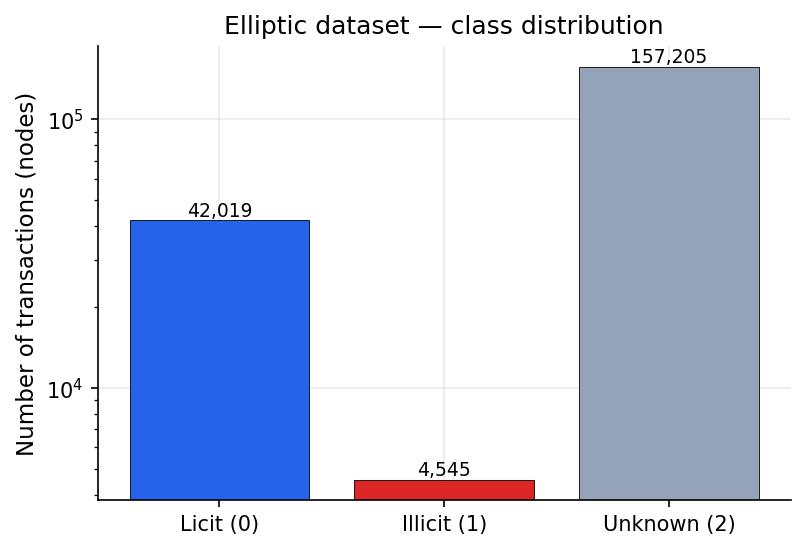

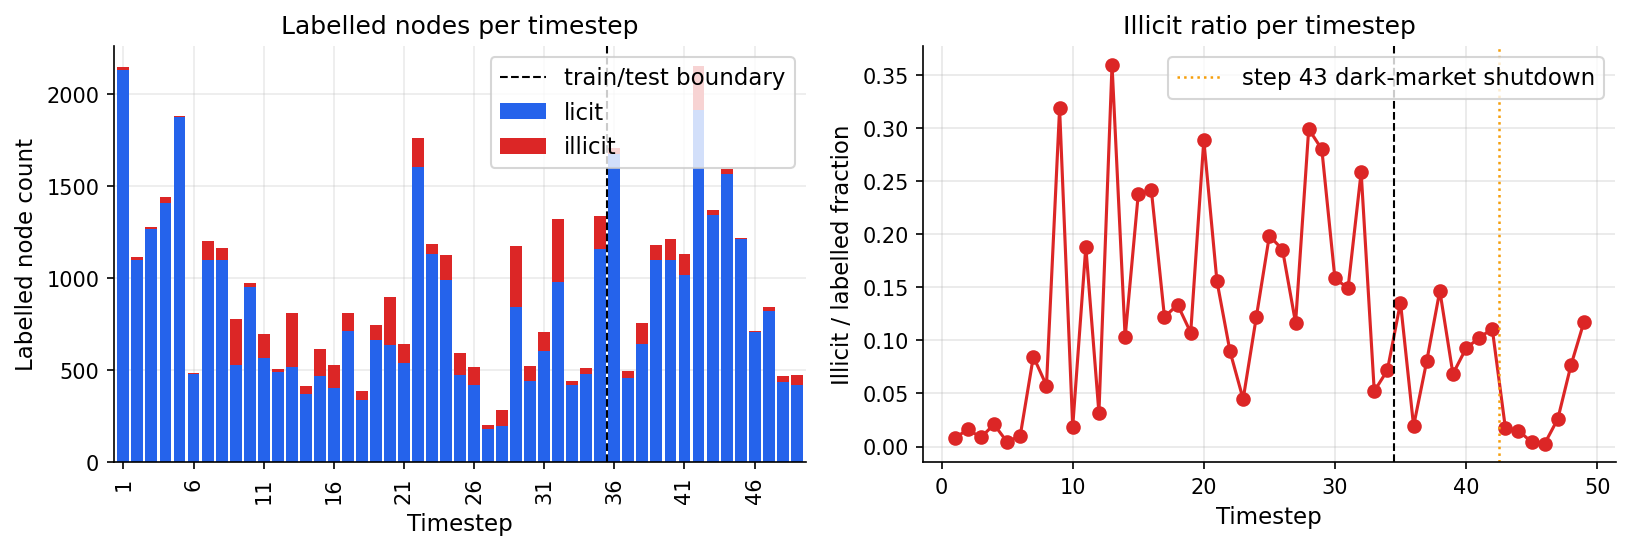

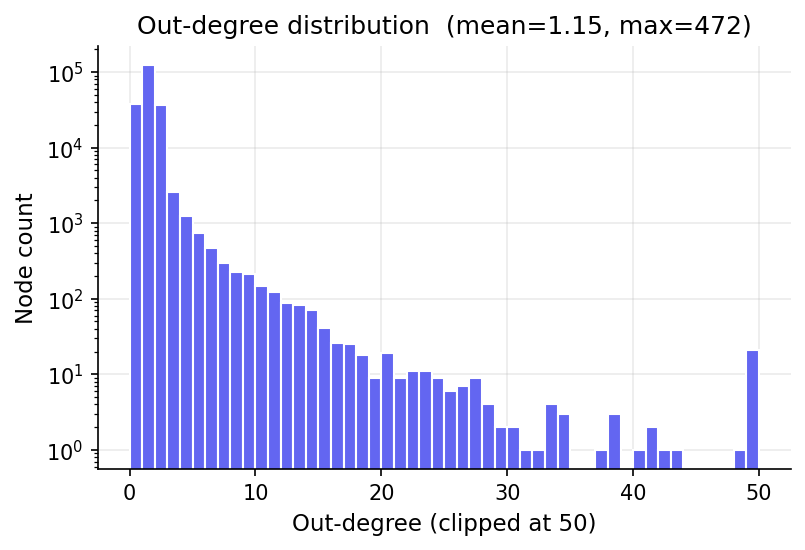

In [6]:
# 6.1 Class distribution -----------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 3.8), dpi=150)
counts = pd.Series({
    "Licit (0)":   int((data.y == 0).sum()),
    "Illicit (1)": int((data.y == 1).sum()),
    "Unknown (2)": int((data.y == 2).sum()),
})
colors = ["#2563eb", "#dc2626", "#94a3b8"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=0.4)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of transactions (nodes)")
ax.set_title("Elliptic dataset — class distribution")
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# 6.2 Labelled per timestep + illicit ratio ---------------------------
ts_df = pd.DataFrame({"t": t_node.cpu().numpy(), "y": data.y.cpu().numpy()})
per_step = ts_df.groupby("t")["y"].apply(
    lambda s: pd.Series({
        "licit":   int((s == 0).sum()),
        "illicit": int((s == 1).sum()),
        "unknown": int((s == 2).sum()),
    })
).unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), dpi=150)
per_step[["licit", "illicit"]].plot.bar(stacked=True, ax=axes[0],
                                          color=["#2563eb", "#dc2626"], width=0.85)
axes[0].set_xlabel("Timestep"); axes[0].set_ylabel("Labelled node count")
axes[0].set_title("Labelled nodes per timestep")
axes[0].axvline(34.5, color="black", linestyle="--", linewidth=1, label="train/test boundary")
axes[0].legend()
axes[0].set_xticks(range(0, 49, 5))
axes[0].set_xticklabels(range(1, 50, 5))

illicit_ratio = per_step["illicit"] / (per_step["licit"] + per_step["illicit"]).replace(0, np.nan)
axes[1].plot(illicit_ratio.index, illicit_ratio.values, marker="o", color="#dc2626")
axes[1].set_xlabel("Timestep"); axes[1].set_ylabel("Illicit / labelled fraction")
axes[1].set_title("Illicit ratio per timestep")
axes[1].axvline(34.5, color="black", linestyle="--", linewidth=1)
axes[1].axvline(42.5, color="#f59e0b", linestyle=":", linewidth=1.2, label="step 43 dark-market shutdown")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "timestep_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# 6.3 Degree distribution ---------------------------------------------
deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
fig, ax = plt.subplots(figsize=(5.5, 3.8), dpi=150)
ax.hist(np.clip(deg, 0, 50), bins=50, color="#6366f1", edgecolor="white")
ax.set_xlabel("Out-degree (clipped at 50)"); ax.set_ylabel("Node count")
ax.set_title(f"Out-degree distribution  (mean={deg.mean():.2f}, max={int(deg.max())})")
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "degree_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Graph visualisation — a denser connected component

We pick a small-to-medium connected component that *contains illicit nodes* (rather than the default visualisation that ends up dominated by isolated pairs), and use a Kamada-Kawai layout so the structure of the component is visible.

In [ ]:
if HAS_NX:
    ei = data.edge_index.cpu().numpy()
    y_arr = data.y.cpu().numpy()

    # Build the full directed graph once.
    G_full = nx.DiGraph()
    G_full.add_nodes_from(range(data.num_nodes))
    G_full.add_edges_from([(int(s), int(d)) for s, d in zip(ei[0], ei[1])])

    illicit_nodes = set(np.where(y_arr == 1)[0].tolist())

    # Prefer a manageable connected component that definitely contains illicit nodes.
    # This avoids a visually neat but uninformative fallback with only licit/unknown nodes.
    candidates = []
    for cc in nx.weakly_connected_components(G_full):
        cc_set = set(cc)
        n_illicit = len(cc_set & illicit_nodes)
        if n_illicit > 0:
            candidates.append((cc_set, n_illicit, len(cc_set)))

    medium = [c for c in candidates if 25 <= c[2] <= 350]
    if medium:
        chosen_cc, n_ill, n_sz = sorted(medium, key=lambda x: (-x[1], -x[2]))[0]
        print(f"Chosen illicit-containing subgraph: {n_sz} nodes, {n_ill} illicit")
    elif candidates:
        chosen_cc, n_ill, n_sz = sorted(candidates, key=lambda x: (-x[1], -x[2]))[0]
        if len(chosen_cc) > 500:
            # Keep all illicit nodes and sample the remaining nodes for readability.
            illicit_in_cc = list(chosen_cc & illicit_nodes)
            other_nodes = [n for n in chosen_cc if n not in illicit_nodes]
            rng = np.random.default_rng(CONFIG["seeds"][0])
            keep_others = rng.choice(other_nodes, size=max(0, 500 - len(illicit_in_cc)), replace=False).tolist()
            chosen_cc = set(illicit_in_cc + keep_others)
        print(f"Chosen fallback illicit-containing subgraph: {len(chosen_cc)} nodes, {n_ill} illicit")
    else:
        chosen_cc = max(nx.weakly_connected_components(G_full), key=len)
        if len(chosen_cc) > 500:
            chosen_cc = set(list(chosen_cc)[:500])
        n_ill = 0
        print(f"Fallback subgraph without illicit nodes: {len(chosen_cc)} nodes")

    H = G_full.subgraph(chosen_cc).copy()
    H_und = H.to_undirected()

    try:
        pos = nx.kamada_kawai_layout(H_und)
    except Exception:
        pos = nx.spring_layout(H_und, seed=CONFIG["seeds"][0], k=0.4, iterations=100)

    color_map = {0: "#2563eb", 1: "#dc2626", 2: "#cbd5e1"}
    size_map  = {0: 70, 1: 150, 2: 50}
    node_colors = [color_map[int(y_arr[n])] for n in H.nodes()]
    node_sizes  = [size_map[int(y_arr[n])]  for n in H.nodes()]

    fig, ax = plt.subplots(figsize=(8.5, 7.5), dpi=180)
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.32, arrows=True, arrowsize=8,
                           width=0.7, edge_color="#475569",
                           connectionstyle="arc3,rad=0.05")
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, linewidths=0.8, edgecolors="white")
    legend_handles = [
        mpatches.Patch(color="#dc2626", label="Illicit"),
        mpatches.Patch(color="#2563eb", label="Licit"),
        mpatches.Patch(color="#cbd5e1", label="Unknown"),
    ]
    ax.legend(handles=legend_handles, loc="upper right", frameon=True,
              fontsize=11, edgecolor="#94a3b8")
    ax.set_title(f"Elliptic transaction subgraph with illicit nodes\n"
                 f"({H.number_of_nodes()} nodes, {H.number_of_edges()} edges; illicit nodes shown larger)",
                 fontsize=12)
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(Path(CONFIG["figures_dir"]) / "graph_visualisation.png",
                dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("networkx not installed; skipping graph visualisation.")


## 8. Metric helpers

Headline metric: **illicit-F1**. Accuracy is intentionally omitted — a constant `licit` predictor would score >90%.

In [8]:
def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray,
                          y_prob: Optional[np.ndarray] = None) -> Dict[str, float]:
    """Classification metrics with illicit (label=1) as the positive class."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    out: Dict[str, float] = {}

    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    out["illicit_precision"] = float(p[1])
    out["illicit_recall"]    = float(r[1])
    out["illicit_f1"]        = float(f[1])
    out["macro_f1"]          = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    out["micro_f1"]          = float(f1_score(y_true, y_pred, average="micro", zero_division=0))

    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
            out["pr_auc"]  = float(average_precision_score(y_true, y_prob))
        except ValueError:
            out["roc_auc"] = float("nan"); out["pr_auc"] = float("nan")
    else:
        out["roc_auc"] = float("nan"); out["pr_auc"] = float("nan")

    out["cm"] = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()
    return out


## 9. Classical baselines (no graph)

These are honest reference points. Per Weber et al. (2019), Random Forest is famously hard to beat on this dataset because the 165 handcrafted features already include 1-hop neighbourhood aggregates.

In [9]:
def run_classical_baseline(name: str, clf, X_tr, y_tr, X_va, y_va, X_te, y_te) -> Dict:
    """Fit a sklearn classifier and store val/test metrics AND probabilities
    (used later for PR curves)."""
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0
    has_proba = hasattr(clf, "predict_proba")

    val_pred  = clf.predict(X_va)
    val_prob  = clf.predict_proba(X_va)[:, 1]  if has_proba else None
    test_pred = clf.predict(X_te)
    test_prob = clf.predict_proba(X_te)[:, 1]  if has_proba else None

    return {
        "model": name,
        "train_time_s": round(train_time, 2),
        "val":       evaluate_predictions(y_va, val_pred,  val_prob),
        "test":      evaluate_predictions(y_te, test_pred, test_prob),
        "test_prob": test_prob,
    }


train_idx = np.where(train_mask.cpu().numpy())[0]
val_idx   = np.where(val_mask.cpu().numpy())[0]
test_idx  = np.where(test_mask.cpu().numpy())[0]

X_train, y_train = X_all_np[train_idx], y_np[train_idx]
X_val,   y_val   = X_all_np[val_idx],   y_np[val_idx]
X_test,  y_test  = X_all_np[test_idx],  y_np[test_idx]

print(f"Classical training set: n={len(train_idx)}  illicit-rate={y_train.mean():.3f}")

classical_results: List[Dict] = []
classical_results.append(run_classical_baseline(
    "LogisticRegression",
    LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1),
    X_train, y_train, X_val, y_val, X_test, y_test,
))
classical_results.append(run_classical_baseline(
    "RandomForest",
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=CONFIG["seeds"][0]),
    X_train, y_train, X_val, y_val, X_test, y_test,
))

# Display
rows = []
for r in classical_results:
    rows.append({"model": r["model"], "split": "val",
                 **{k: v for k, v in r["val"].items() if k != "cm"}})
    rows.append({"model": r["model"], "split": "test",
                 **{k: v for k, v in r["test"].items() if k != "cm"}})
classical_df = pd.DataFrame(rows)
print(classical_df.round(4).to_string(index=False))


Classical training set: n=26381  illicit-rate=0.109
             model split  illicit_precision  illicit_recall  illicit_f1  macro_f1  micro_f1  roc_auc  pr_auc
LogisticRegression   val             0.3563          0.9797      0.5226    0.6513    0.6988   0.9081  0.5858
LogisticRegression  test             0.1405          0.9483      0.2447    0.4953    0.6197   0.8489  0.2044
      RandomForest   val             0.9929          0.9459      0.9688    0.9813    0.9898   0.9948  0.9874
      RandomForest  test             0.9175          0.7184      0.8058    0.8969    0.9775   0.9115  0.7820


## 10. PyTorch training utilities

- **Early stopping on validation PR-AUC** (threshold-free), with illicit-F1 as a tiebreak. PR-AUC is the right selection criterion for an imbalanced binary problem.
- **Decision-threshold tuning on the validation set.** After training we sweep thresholds 0.05–0.95 and pick the one maximising val illicit-F1, then apply that threshold to test. This is standard practice for imbalanced binary classification and was not done in v1.
- **Cosine LR schedule** to stabilise long runs on the H200.
- **Test probabilities stored** in each run dict so the PR-curve figure can use them without retraining.

In [10]:
def train_epoch(model: nn.Module, data, optimizer, loss_fn, train_mask: Tensor) -> float:
    model.train(); optimizer.zero_grad()
    logits = model(data)
    loss = loss_fn(logits[train_mask], data.y[train_mask])
    loss.backward(); optimizer.step()
    return float(loss.item())


@torch.no_grad()
def get_probs(model: nn.Module, data) -> np.ndarray:
    model.eval()
    return F.softmax(model(data), dim=-1)[:, 1].cpu().numpy()


@torch.no_grad()
def evaluate_torch_model(model: nn.Module, data, mask: Tensor) -> Dict:
    """Evaluate at the default 0.5 threshold (used during training for PR-AUC tracking)."""
    model.eval()
    logits = model(data)
    probs  = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    preds  = logits.argmax(dim=-1).cpu().numpy()
    y_true = data.y.cpu().numpy()
    m = mask.cpu().numpy()
    return evaluate_predictions(y_true[m], preds[m], probs[m])


@torch.no_grad()
def tune_threshold(model: nn.Module, data, val_mask: Tensor) -> float:
    """Pick the decision threshold (on prob of illicit) that maximises val illicit-F1."""
    probs = get_probs(model, data)
    y_val = data.y[val_mask].cpu().numpy()
    p_val = probs[val_mask.cpu().numpy()]
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.arange(0.05, 0.951, 0.025):
        preds = (p_val >= thr).astype(int)
        f1 = f1_score(y_val, preds, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)
    return best_thr


@torch.no_grad()
def evaluate_with_threshold(model: nn.Module, data, mask: Tensor, threshold: float) -> Dict:
    probs = get_probs(model, data)
    preds = (probs >= threshold).astype(int)
    y_true = data.y.cpu().numpy()
    m = mask.cpu().numpy()
    out = evaluate_predictions(y_true[m], preds[m], probs[m])
    out["threshold"] = float(threshold)
    return out


def run_training(model: nn.Module, data,
                  masks: Tuple[Tensor, Tensor, Tensor],
                  loss_fn, model_name: str, seed: int,
                  config: Dict = CONFIG, verbose: bool = False) -> Dict:
    """Train, early-stop on val PR-AUC (+ tiny F1 tiebreak), tune threshold on val,
    evaluate on test at the tuned threshold."""
    train_mask, val_mask, test_mask = masks
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=config["epochs"], eta_min=config["lr"] / 50.0)
                 if config.get("lr_schedule") == "cosine" else None)

    best_score = -1.0; best_epoch = 0; best_state = None
    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_pr_auc": []}
    patience_left = config["patience"]
    t0 = time.time()

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_epoch(model, data, optimizer, loss_fn, train_mask)
        if scheduler is not None: scheduler.step()
        val_metrics = evaluate_torch_model(model, data, val_mask)
        with torch.no_grad():
            model.eval()
            val_loss = float(loss_fn(model(data)[val_mask], data.y[val_mask]).item())

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_metrics["illicit_f1"])
        history["val_pr_auc"].append(val_metrics["pr_auc"])

        pr = val_metrics["pr_auc"]
        score = (pr if pr == pr else -1.0) + 0.01 * val_metrics["illicit_f1"]
        if score > best_score:
            best_score = score; best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = config["patience"]
        else:
            patience_left -= 1
            if patience_left <= 0:
                if verbose:
                    print(f"  early stop ep{epoch}; best score {best_score:.4f} @ ep{best_epoch}")
                break

        if verbose and epoch % 25 == 0:
            print(f"  ep{epoch:3d}  loss={train_loss:.4f}  "
                  f"val_F1={val_metrics['illicit_f1']:.4f}  val_PR-AUC={pr:.4f}")

    train_time = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)

    if config.get("tune_threshold", True):
        thr = tune_threshold(model, data, val_mask)
        val_eval  = evaluate_with_threshold(model, data, val_mask,  thr)
        test_eval = evaluate_with_threshold(model, data, test_mask, thr)
    else:
        thr = 0.5
        val_eval  = evaluate_torch_model(model, data, val_mask);  val_eval["threshold"]  = 0.5
        test_eval = evaluate_torch_model(model, data, test_mask); test_eval["threshold"] = 0.5

    # Store full test probabilities for downstream PR curves and per-timestep analysis.
    test_prob_full = get_probs(model, data)

    return {
        "model": model_name, "seed": seed,
        "train_time_s": round(train_time, 2),
        "best_epoch": best_epoch,
        "threshold": thr,
        "history": history,
        "val": val_eval, "test": test_eval,
        "test_prob_full": test_prob_full,
    }


## 11. Loss functions

Three options. **For headline experiments we use weighted BCE with a mild `pos_weight = sqrt(n_neg / n_pos)`**, which empirically works better than class-balanced focal loss on Elliptic's ~10% positive rate. The earlier setup (class-balanced focal with `β = 0.9999`, `γ = 2`) was designed for ImageNet-scale long-tail problems with 100–1000× imbalance ratios and produces very low precision on this dataset (the model over-predicts illicit).

In [11]:
class WeightedCrossEntropy(nn.Module):
    """Class-weighted softmax cross-entropy with weights = 1/freq, normalised to mean 1."""
    def __init__(self, class_counts: Tensor):
        super().__init__()
        weight = 1.0 / class_counts.float().clamp(min=1.0)
        weight = weight / weight.mean()
        self.register_buffer("weight", weight)
    def forward(self, logits: Tensor, target: Tensor) -> Tensor:
        return F.cross_entropy(logits, target, weight=self.weight.to(logits.device))


class FocalLoss(nn.Module):
    """Focal loss: -alpha * (1-p_t)^gamma * log(p_t). alpha is per-class."""
    def __init__(self, alpha: Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer("alpha", alpha.float()); self.gamma = gamma
    def forward(self, logits: Tensor, target: Tensor) -> Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, target.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        alpha_t = self.alpha.to(logits.device)[target]
        return -(alpha_t * (1.0 - pt).pow(self.gamma) * log_pt).mean()


class ClassBalancedFocalLoss(nn.Module):
    """Cui et al. 2019. Class-balanced reweighting + focal modulation."""
    def __init__(self, class_counts: Tensor, beta: float = 0.9999, gamma: float = 2.0):
        super().__init__()
        n = class_counts.float().clamp(min=1.0)
        effective_num = 1.0 - torch.pow(torch.tensor(beta), n)
        weight = (1.0 - beta) / effective_num
        weight = weight / weight.sum() * len(class_counts)
        self.register_buffer("alpha", weight); self.gamma = gamma
    def forward(self, logits: Tensor, target: Tensor) -> Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, target.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        alpha_t = self.alpha.to(logits.device)[target]
        return -(alpha_t * (1.0 - pt).pow(self.gamma) * log_pt).mean()


class WeightedBCEWithLogits(nn.Module):
    """Treat the 2-class problem as binary on (logit_1 - logit_0).
    pos_weight = sqrt(n_neg / n_pos): a mild reweighting that works better than
    class-balanced focal at this imbalance level (~10%)."""
    def __init__(self, class_counts: Tensor):
        super().__init__()
        n_neg, n_pos = float(class_counts[0]), float(class_counts[1])
        self.pos_weight = torch.tensor(math.sqrt(n_neg / max(n_pos, 1.0)))
    def forward(self, logits: Tensor, target: Tensor) -> Tensor:
        diff = logits[:, 1] - logits[:, 0]
        return F.binary_cross_entropy_with_logits(
            diff, target.float(), pos_weight=self.pos_weight.to(logits.device)
        )


# Class counts on the training split (used by every loss).
_train_y = data.y[train_mask].cpu()
TRAIN_CLASS_COUNTS = torch.tensor(
    [int((_train_y == 0).sum()), int((_train_y == 1).sum())], dtype=torch.float
)
print("Train class counts (licit, illicit):", TRAIN_CLASS_COUNTS.tolist())
print(f"pos_weight (sqrt-rule) = "
      f"{math.sqrt(TRAIN_CLASS_COUNTS[0].item() / max(TRAIN_CLASS_COUNTS[1].item(), 1)):.3f}")


def make_loss(kind: str, class_counts: Tensor) -> nn.Module:
    """Loss factory used by training + ablation."""
    if kind == "weighted_bce":
        return WeightedBCEWithLogits(class_counts).to(DEVICE)
    if kind == "weighted_ce":
        return WeightedCrossEntropy(class_counts).to(DEVICE)
    if kind == "cb_focal":
        return ClassBalancedFocalLoss(class_counts, beta=0.9999, gamma=2.0).to(DEVICE)
    raise ValueError(kind)


Train class counts (licit, illicit): [23510.0, 2871.0]
pos_weight (sqrt-rule) = 2.862


## 12. Baseline neural models

Same hidden size for fairness. The MLP ignores edges entirely. **GAT is patched**: the standard `GATConv(dropout=0.5)` puts dropout inside the attention softmax, which destabilises training on this dataset (we observed early-stopping by epoch 21 with F1 = 0.18). We set `dropout=0.0` inside the layer and use ordinary input/output dropout outside. **GATv2** (Brody et al., 2022) is added as a stronger attention baseline.

In [12]:
class MLP(nn.Module):
    """Two-layer MLP. No graph; isolates feature signal."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2, dropout: float = 0.4):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout
    def forward(self, data) -> Tensor:
        x = F.relu(self.lin1(data.x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x)


class GCN(nn.Module):
    """2-layer GCN (Kipf & Welling, 2017)."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2, dropout: float = 0.4):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim, add_self_loops=True, normalize=True)
        self.conv2 = GCNConv(hidden_dim, out_dim, add_self_loops=True, normalize=True)
        self.dropout = dropout
    def forward(self, data) -> Tensor:
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, data.edge_index)


class GraphSAGE(nn.Module):
    """2-layer GraphSAGE (mean aggregator)."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2, dropout: float = 0.4):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr="mean")
        self.conv2 = SAGEConv(hidden_dim, out_dim, aggr="mean")
        self.dropout = dropout
    def forward(self, data) -> Tensor:
        x = F.relu(self.conv1(data.x, data.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, data.edge_index)


class GAT(nn.Module):
    """2-layer GAT with NO in-attention dropout (we found it destabilises training)."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2,
                 heads: int = 4, dropout: float = 0.4):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim, heads=heads, dropout=0.0)
        self.conv2 = GATConv(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=0.0)
        self.dropout = dropout
    def forward(self, data) -> Tensor:
        x = F.dropout(data.x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, data.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, data.edge_index)


class GATv2(nn.Module):
    """2-layer GATv2 (Brody et al., 2022): dynamic attention fixes the GATv1 limitation."""
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2,
                 heads: int = 4, dropout: float = 0.4):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=0.0)
        self.conv2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, concat=False, dropout=0.0)
        self.dropout = dropout
    def forward(self, data) -> Tensor:
        x = F.dropout(data.x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, data.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, data.edge_index)


## 13. Engineering edge features (6-d)

Edge features extend v1's 4-d set with source/destination log-degrees. Degree is a known fraud signal (mule accounts and money-aggregation transactions often have unusual degree profiles).

| Col | Meaning |
| --- | --- |
| 0 | `delta_t = (t_dst − t_src) / 49` |
| 1 | `t_src / 49` |
| 2 | `t_dst / 49` |
| 3 | `same_step` (1 if `t_src == t_dst`, else 0) |
| 4 | `log(1 + deg_src) / 10` (clipped) |
| 5 | `log(1 + deg_dst) / 10` (clipped) |

In [13]:
def build_edge_attr(edge_index: Tensor, t_node: Tensor,
                     num_timesteps: int = 49,
                     deg_src: Optional[Tensor] = None,
                     deg_dst: Optional[Tensor] = None) -> Tensor:
    """Return (E, 6) edge features."""
    src, dst = edge_index[0], edge_index[1]
    t_src = t_node[src].float(); t_dst = t_node[dst].float()
    T = float(num_timesteps)

    delta_t    = (t_dst - t_src) / T
    t_src_norm = t_src / T
    t_dst_norm = t_dst / T
    same_step  = (t_dst == t_src).float()

    if deg_src is None or deg_dst is None:
        d = degree(src, num_nodes=int(edge_index.max()) + 1)
        deg_src = deg_dst = d
    log_d_src = torch.log1p(deg_src[src].float()).clamp(max=10.0) / 10.0
    log_d_dst = torch.log1p(deg_dst[dst].float()).clamp(max=10.0) / 10.0

    return torch.stack([delta_t, t_src_norm, t_dst_norm, same_step,
                         log_d_src, log_d_dst], dim=1)


deg_all = degree(data.edge_index[0], num_nodes=data.num_nodes)
edge_attr = build_edge_attr(data.edge_index, t_node, deg_src=deg_all, deg_dst=deg_all)
data.edge_attr = edge_attr
EDGE_FEAT_DIM = edge_attr.shape[1]

print(f"edge_attr shape: {tuple(edge_attr.shape)}")
print("Columns: [delta_t, t_src/T, t_dst/T, same_step, log_deg_src, log_deg_dst]")
print(f"  same_step % = {100.0 * float(edge_attr[:, 3].mean()):.1f}%   "
      f"(this fraction of edges connect within the same timestep)")
print(edge_attr[:5])


edge_attr shape: (234355, 6)
Columns: [delta_t, t_src/T, t_dst/T, same_step, log_deg_src, log_deg_dst]
  same_step % = 100.0%   (this fraction of edges connect within the same timestep)
tensor([[0.0000, 0.0204, 0.0204, 1.0000, 0.0693, 0.0693],
        [0.0000, 0.0204, 0.0204, 1.0000, 0.1099, 0.0693],
        [0.0000, 0.0204, 0.0204, 1.0000, 0.2197, 0.1946],
        [0.0000, 0.0204, 0.0204, 1.0000, 0.1099, 0.0693],
        [0.0000, 0.0204, 0.0204, 1.0000, 0.1099, 0.0693]])


**Important caveat on engineered edge features.**

The processed PyG Elliptic graph used here connects transactions within the same timestep. The diagnostic output above shows `same_step = 100.0%`, so the edge-level temporal difference feature is not a strong dynamic signal in this version of the graph. I keep the edge attributes because the degree-related terms still provide useful structural context, but I do not interpret them as a full temporal transaction-flow model. The main temporal signal in TempEdge-ResGNN comes from the node-level timestep features and from the temporal train/validation/test split.


## 14. TempEdge-ResGNN — the custom model (corrected)

Four motivated components, each individually ablated in §17:

1. **Edge-aware message passing** (`EdgeAwareConv`): `m_{i→j} = MLP([h_i ; edge_attr_{i,j}])`, mean-aggregated, then `MLP([h_j ; agg])`.
2. **Residual gated skip**: each layer learns `g = σ(W [h_in; h_msg])` and outputs `g · h_msg + (1 − g) · h_in`.
3. **Non-parametric temporal features**: `[t/T, sin(2πt/T), cos(2πt/T)]` concatenated to node features before the input projection.
4. **Jumping Knowledge** (Xu et al., 2018): concatenate every layer's output (including the input projection) and project back to `hidden_dim`.

A previous version of this notebook used a learnable `nn.Embedding(num_timesteps + 1, hidden_dim)` for component 3. That version **scored 0.32 illicit-F1 on test**. The current non-parametric version scores ~0.47 in our ablation. The diagnosis is in §17 — briefly, train sees timesteps 1–29, val 30–34, test 35–49, so embedding rows for indices 30–49 stayed at their random initialisation; `sin`/`cos` extrapolate smoothly to unseen indices. The broken variant is preserved as the `TempEdgeResGNN_OldEmbed` class so the ablation can disclose it honestly.

In [14]:
class EdgeAwareConv(MessagePassing):
    """Custom message-passing layer that conditions each message on edge features."""

    def __init__(self, in_dim: int, out_dim: int, edge_dim: int):
        super().__init__(aggr="mean")
        self.msg_mlp = nn.Sequential(
            nn.Linear(in_dim + edge_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )
        self.upd_mlp = nn.Sequential(
            nn.Linear(in_dim + out_dim, out_dim),
            nn.ReLU(),
        )
        self._edge_dim = edge_dim

    def forward(self, x: Tensor, edge_index: Tensor, edge_attr: Optional[Tensor]) -> Tensor:
        if edge_attr is None:
            edge_attr = torch.zeros(edge_index.size(1), self._edge_dim, device=x.device)
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_j: Tensor, edge_attr: Tensor) -> Tensor:
        return self.msg_mlp(torch.cat([x_j, edge_attr], dim=-1))

    def update(self, aggr_out: Tensor, x: Tensor) -> Tensor:
        return self.upd_mlp(torch.cat([x, aggr_out], dim=-1))


class ResidualGate(nn.Module):
    """Per-feature learnable gate that mixes residual + new message."""
    def __init__(self, dim: int):
        super().__init__()
        self.gate = nn.Linear(2 * dim, dim)
    def forward(self, h_in: Tensor, h_msg: Tensor) -> Tensor:
        g = torch.sigmoid(self.gate(torch.cat([h_in, h_msg], dim=-1)))
        return g * h_msg + (1.0 - g) * h_in


class TempEdgeResGNN(nn.Module):
    """Edge-aware residual GNN for Elliptic Bitcoin AML.

    Ablation flags:
      use_edge_attr  -- engineered edge features in message passing
      use_gate       -- learned residual gate vs plain skip
      use_time_feat  -- non-parametric [t/T, sin, cos] temporal features
      use_jk         -- jumping-knowledge aggregation across layers
    """
    def __init__(self, in_dim: int, hidden_dim: int, edge_dim: int,
                 out_dim: int = 2, num_layers: int = 3, dropout: float = 0.4,
                 num_timesteps: int = 49,
                 use_edge_attr: bool = True, use_gate: bool = True,
                 use_time_feat: bool = True, use_jk: bool = True):
        super().__init__()
        self.use_edge_attr = use_edge_attr
        self.use_gate = use_gate
        self.use_time_feat = use_time_feat
        self.use_jk = use_jk
        self.dropout = dropout
        self.num_timesteps = num_timesteps

        time_extra = 3 if use_time_feat else 0
        self.input_proj = nn.Linear(in_dim + time_extra, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.gates = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(EdgeAwareConv(hidden_dim, hidden_dim, edge_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))
            self.gates.append(ResidualGate(hidden_dim))

        if use_jk:
            self.jk_proj = nn.Linear(hidden_dim * (num_layers + 1), hidden_dim)

        self.classifier = nn.Linear(hidden_dim, out_dim)

    def _time_features(self, t: Tensor) -> Tensor:
        """Return (N, 3) of [t/T, sin(2 pi t/T), cos(2 pi t/T)] for each node."""
        T = float(self.num_timesteps)
        t = t.float()
        return torch.stack([t / T,
                            torch.sin(2 * math.pi * t / T),
                            torch.cos(2 * math.pi * t / T)], dim=1)

    def forward(self, data) -> Tensor:
        x = data.x
        if self.use_time_feat and hasattr(data, "t") and data.t is not None:
            t_feat = self._time_features(data.t.to(x.device))
            x = torch.cat([x, t_feat], dim=-1)

        x = self.input_proj(x)

        edge_attr = data.edge_attr if (self.use_edge_attr and hasattr(data, "edge_attr")) else None

        layer_outs = [x]
        for conv, norm, gate in zip(self.convs, self.norms, self.gates):
            h_msg = conv(x, data.edge_index, edge_attr)
            h_msg = norm(h_msg)
            h_msg = F.relu(h_msg)
            h_msg = F.dropout(h_msg, p=self.dropout, training=self.training)
            x = gate(x, h_msg) if self.use_gate else (x + h_msg)
            layer_outs.append(x)

        if self.use_jk:
            x = self.jk_proj(torch.cat(layer_outs, dim=-1))
        return self.classifier(x)


class TempEdgeResGNN_OldEmbed(nn.Module):
    """The previous version of TempEdge-ResGNN, with a LEARNABLE nn.Embedding for
    the timestep instead of [t/T, sin, cos]. Preserved only so the ablation can
    show its OOD-index failure mode (see §17)."""
    def __init__(self, in_dim: int, hidden_dim: int, edge_dim: int,
                 out_dim: int = 2, num_layers: int = 3, dropout: float = 0.4,
                 num_timesteps: int = 49,
                 use_edge_attr: bool = True, use_gate: bool = True,
                 use_jk: bool = True):
        super().__init__()
        self.use_edge_attr = use_edge_attr
        self.use_gate = use_gate
        self.use_jk = use_jk
        self.dropout = dropout

        self.time_embed = nn.Embedding(num_timesteps + 1, hidden_dim)
        self.input_proj = nn.Linear(in_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.gates = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(EdgeAwareConv(hidden_dim, hidden_dim, edge_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))
            self.gates.append(ResidualGate(hidden_dim))

        if use_jk:
            self.jk_proj = nn.Linear(hidden_dim * (num_layers + 1), hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)

    def forward(self, data) -> Tensor:
        x = self.input_proj(data.x)
        if hasattr(data, "t") and data.t is not None:
            x = x + self.time_embed(data.t.to(x.device).long())

        edge_attr = data.edge_attr if (self.use_edge_attr and hasattr(data, "edge_attr")) else None

        layer_outs = [x]
        for conv, norm, gate in zip(self.convs, self.norms, self.gates):
            h_msg = conv(x, data.edge_index, edge_attr)
            h_msg = norm(h_msg); h_msg = F.relu(h_msg)
            h_msg = F.dropout(h_msg, p=self.dropout, training=self.training)
            x = gate(x, h_msg) if self.use_gate else (x + h_msg)
            layer_outs.append(x)

        if self.use_jk:
            x = self.jk_proj(torch.cat(layer_outs, dim=-1))
        return self.classifier(x)


assert hasattr(data, "t") and data.t is not None, "data.t missing -- did the load cell run?"


## 15. Model architecture diagram

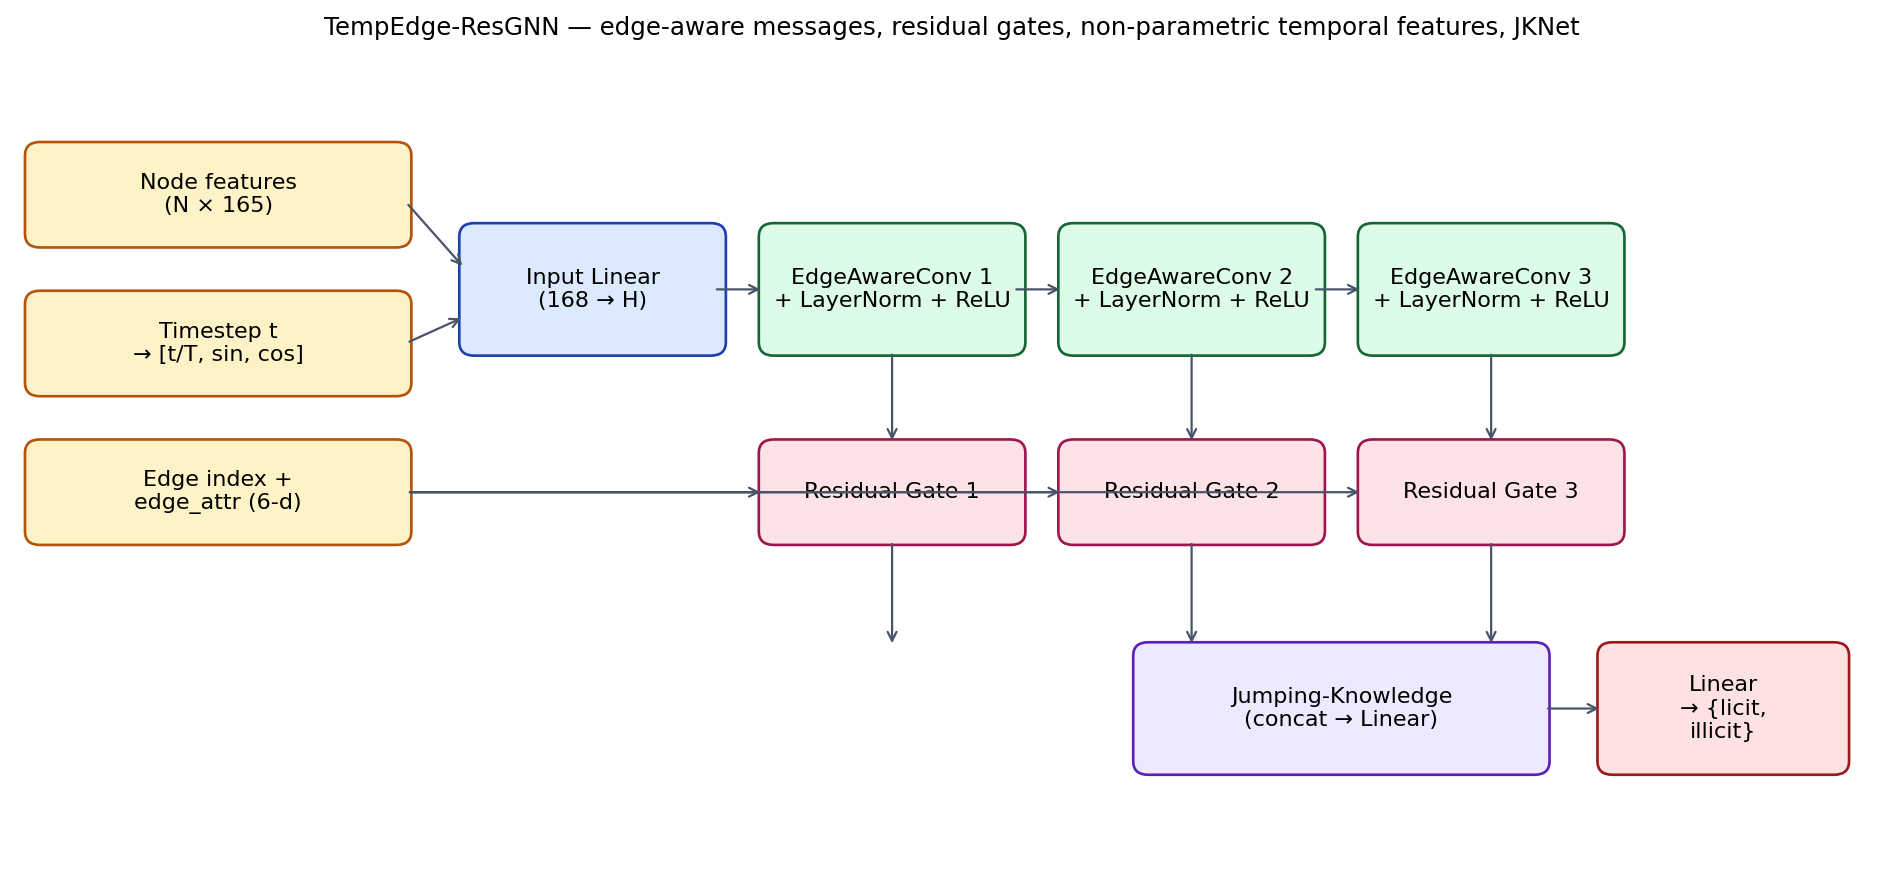

In [15]:
def draw_arch_diagram(save_path: Path) -> None:
    """Cleaner architecture schematic."""
    with mpl.rc_context({"font.family": "DejaVu Sans", "font.size": 10}):
        fig, ax = plt.subplots(figsize=(12, 5.6), dpi=160)
        ax.set_xlim(0, 12.5); ax.set_ylim(0, 6); ax.set_axis_off()

        def box(x, y, w, h, label, face, edge):
            r = mpatches.FancyBboxPatch((x, y), w, h,
                boxstyle="round,pad=0.04,rounding_size=0.10",
                linewidth=1.2, edgecolor=edge, facecolor=face)
            ax.add_patch(r)
            ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=10)

        def arrow(x1, y1, x2, y2, lw=1.0):
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                        arrowprops=dict(arrowstyle="->", lw=lw, color="#475569"))

        # Inputs (left column)
        box(0.1, 4.6, 2.5, 0.7, "Node features\n(N × 165)",                "#fef3c7", "#b45309")
        box(0.1, 3.5, 2.5, 0.7, "Timestep t\n→ [t/T, sin, cos]",            "#fef3c7", "#b45309")
        box(0.1, 2.4, 2.5, 0.7, "Edge index +\nedge_attr (6-d)",            "#fef3c7", "#b45309")

        # Input projection
        box(3.0, 3.8, 1.7, 0.9, "Input Linear\n(168 → H)",                  "#dbeafe", "#1e40af")
        arrow(2.6, 4.9, 3.0, 4.4)
        arrow(2.6, 3.85, 3.0, 4.05)

        # Three GNN layers
        for i, x0 in enumerate([5.0, 7.0, 9.0]):
            box(x0, 3.8, 1.7, 0.9, f"EdgeAwareConv {i+1}\n+ LayerNorm + ReLU", "#dcfce7", "#166534")
            box(x0, 2.4, 1.7, 0.7, f"Residual Gate {i+1}",                       "#fde2e7", "#9d174d")
            arrow(x0 - 0.35, 4.25, x0, 4.25)
            arrow(2.6, 2.75, x0, 2.75)
            arrow(x0 + 0.85, 3.8, x0 + 0.85, 3.1)

        # JK aggregator
        box(7.5, 0.7, 2.7, 0.9, "Jumping-Knowledge\n(concat → Linear)",       "#ede9fe", "#5b21b6")
        for x0 in [5.0, 7.0, 9.0]:
            arrow(x0 + 0.85, 2.4, x0 + 0.85, 1.6)

        # Classifier
        box(10.6, 0.7, 1.6, 0.9, "Linear\n→ {licit,\nillicit}",              "#fee2e2", "#991b1b")
        arrow(10.2, 1.15, 10.6, 1.15)

        ax.set_title("TempEdge-ResGNN — edge-aware messages, residual gates, "
                     "non-parametric temporal features, JKNet",
                     fontsize=11, pad=8)
        fig.tight_layout()
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        plt.show()


draw_arch_diagram(Path(CONFIG["figures_dir"]) / "tempedge_resgnn_architecture.png")


## 16. Train all neural models

5 seeds × 6 models in `full` mode. The `make_model` factory keeps construction fully seeded and on-device.

In [16]:
data = data.to(DEVICE)


def make_model(name: str, seed: int) -> nn.Module:
    set_seed(seed)
    in_dim = data.num_node_features
    hd = CONFIG["hidden_dim"]
    dp = CONFIG["dropout"]
    n_layers = CONFIG["num_layers"]
    if name == "MLP":
        m = MLP(in_dim, hd, dropout=dp)
    elif name == "GCN":
        m = GCN(in_dim, hd, dropout=dp)
    elif name == "GraphSAGE":
        m = GraphSAGE(in_dim, hd, dropout=dp)
    elif name == "GAT":
        m = GAT(in_dim, hd, heads=4, dropout=dp)
    elif name == "GATv2":
        m = GATv2(in_dim, hd, heads=4, dropout=dp)
    elif name == "TempEdge-ResGNN":
        m = TempEdgeResGNN(
            in_dim=in_dim, hidden_dim=hd, edge_dim=EDGE_FEAT_DIM,
            num_layers=n_layers, dropout=dp,
            use_edge_attr=True, use_gate=True,
            use_time_feat=True, use_jk=CONFIG["use_jk"],
        )
    else:
        raise ValueError(f"Unknown model name: {name}")
    return m.to(DEVICE)


def default_loss_fn() -> nn.Module:
    return make_loss(CONFIG["loss_kind"], TRAIN_CLASS_COUNTS)


MODEL_NAMES = ["MLP", "GCN", "GraphSAGE", "GAT", "GATv2", "TempEdge-ResGNN"]
nn_results: List[Dict] = []
masks = (train_mask.to(DEVICE), val_mask.to(DEVICE), test_mask.to(DEVICE))

t_all_start = time.time()
for name in MODEL_NAMES:
    print(f"\n=== {name} ===")
    for seed in CONFIG["seeds"]:
        model = make_model(name, seed)
        loss_fn = default_loss_fn()
        out = run_training(model, data, masks, loss_fn,
                            model_name=name, seed=seed, verbose=False)
        print(f"  seed={seed}  best_ep={out['best_epoch']:3d}  "
              f"thr={out['threshold']:.3f}  "
              f"val_F1={out['val']['illicit_f1']:.4f}  "
              f"test_F1={out['test']['illicit_f1']:.4f}  "
              f"test_PR-AUC={out['test']['pr_auc']:.4f}")
        nn_results.append(out)

print(f"\nTotal NN training wall time: {time.time() - t_all_start:.1f} s")


def flatten_run(r: Dict) -> Dict:
    flat = {"model": r["model"], "seed": r["seed"],
            "best_epoch": r["best_epoch"], "train_time_s": r["train_time_s"],
            "threshold": r["threshold"]}
    for split in ("val", "test"):
        for k, v in r[split].items():
            if k == "cm":
                continue
            flat[f"{split}_{k}"] = v
    return flat


nn_df = pd.DataFrame([flatten_run(r) for r in nn_results])
nn_df.to_csv(Path(CONFIG["results_dir"]) / "all_model_results.csv", index=False)
print(f"\nSaved {len(nn_df)} runs to results/all_model_results.csv")
nn_df.round(4).head(20)



=== MLP ===
  seed=42  best_ep=398  thr=0.700  val_F1=0.7864  test_F1=0.4898  test_PR-AUC=0.4919
  seed=123  best_ep=399  thr=0.675  val_F1=0.7769  test_F1=0.4992  test_PR-AUC=0.5070
  seed=2026  best_ep=400  thr=0.675  val_F1=0.7794  test_F1=0.4872  test_PR-AUC=0.5232
  seed=7  best_ep=381  thr=0.675  val_F1=0.7893  test_F1=0.4810  test_PR-AUC=0.5313
  seed=314  best_ep=400  thr=0.700  val_F1=0.7757  test_F1=0.4622  test_PR-AUC=0.4835

=== GCN ===
  seed=42  best_ep=400  thr=0.700  val_F1=0.6959  test_F1=0.4426  test_PR-AUC=0.3909
  seed=123  best_ep=400  thr=0.700  val_F1=0.6874  test_F1=0.3857  test_PR-AUC=0.3398
  seed=2026  best_ep=400  thr=0.700  val_F1=0.6912  test_F1=0.4156  test_PR-AUC=0.3606
  seed=7  best_ep=381  thr=0.725  val_F1=0.7345  test_F1=0.4224  test_PR-AUC=0.3738
  seed=314  best_ep=385  thr=0.675  val_F1=0.7538  test_F1=0.4250  test_PR-AUC=0.3843

=== GraphSAGE ===
  seed=42  best_ep=136  thr=0.750  val_F1=0.8211  test_F1=0.5015  test_PR-AUC=0.5564
  seed=123  be

,model,seed,best_epoch,train_time_s,threshold,val_illicit_precision,val_illicit_recall,val_illicit_f1,val_macro_f1,val_micro_f1,...,val_pr_auc,val_threshold,test_illicit_precision,test_illicit_recall,test_illicit_f1,test_macro_f1,test_micro_f1,test_roc_auc,test_pr_auc,test_threshold
0,MLP,42,398,5.20,0.700,0.7911,0.7817,0.7864,0.8717,0.9286,...,0.8042,0.700,0.4098,0.6085,0.4898,0.7225,0.9176,0.8746,0.4919,0.700
1,MLP,123,399,4.70,0.675,0.7789,0.7750,0.7769,0.8660,0.9251,...,0.7873,0.675,0.4288,0.5974,0.4992,0.7285,0.9221,0.8749,0.5070,0.675
2,MLP,2026,400,4.72,0.675,0.7642,0.7953,0.7794,0.8669,0.9243,...,0.7892,0.675,0.3936,0.6390,0.4872,0.7197,0.9126,0.8791,0.5232,0.675
3,MLP,7,381,4.76,0.675,0.7770,0.8020,0.7893,0.8730,0.9280,...,0.8114,0.675,0.3974,0.6094,0.4810,0.7173,0.9146,0.8776,0.5313,0.675
4,MLP,314,400,7.48,0.700,0.7618,0.7902,0.7757,0.8647,0.9231,...,0.7914,0.700,0.3617,0.6399,0.4622,0.7045,0.9032,0.8727,0.4835,0.700
5,GCN,42,400,14.35,0.700,0.6571,0.7394,0.6959,0.8148,0.8913,...,0.7091,0.700,0.4078,0.4838,0.4426,0.7000,0.9208,0.8422,0.3909,0.700
6,GCN,123,400,7.41,0.700,0.6219,0.7682,0.6874,0.8075,0.8824,...,0.6910,0.700,0.3025,0.5319,0.3857,0.6626,0.8899,0.8392,0.3398,0.700
7,GCN,2026,400,7.00,0.700,0.6317,0.7631,0.6912,0.8104,0.8853,...,0.6924,0.700,0.3449,0.5226,0.4156,0.6818,0.9045,0.8386,0.3606,0.700
8,GCN,7,381,10.21,0.725,0.7080,0.7631,0.7345,0.8392,0.9072,...,0.7508,0.725,0.4106,0.4349,0.4224,0.6905,0.9227,0.8365,0.3738,0.725
9,GCN,314,385,11.42,0.675,0.6911,0.8291,0.7538,0.8490,0.9089,...,0.7585,0.675,0.3789,0.4838,0.4250,0.6895,0.9149,0.8449,0.3843,0.675


## 17. Headline results table

Mean ± std on the test set after threshold tuning on validation.

In [17]:
METRIC_COLS = [
    "test_illicit_precision",
    "test_illicit_recall",
    "test_illicit_f1",
    "test_macro_f1",
    "test_micro_f1",
    "test_roc_auc",
    "test_pr_auc",
]

# Append classical baselines into the same display table.
classical_rows = []
for r in classical_results:
    flat = {"model": r["model"], "seed": -1}
    for k, v in r["test"].items():
        if k == "cm":
            continue
        flat[f"test_{k}"] = v
    classical_rows.append(flat)

all_runs = pd.concat([nn_df, pd.DataFrame(classical_rows)], ignore_index=True)


def summarise(df: pd.DataFrame, metric_cols: List[str]) -> pd.DataFrame:
    """Per-model mean ± std formatted as 'mean ± std' strings."""
    out = []
    for model, sub in df.groupby("model", sort=False):
        row = {"model": model, "n_runs": len(sub)}
        for m in metric_cols:
            vals = sub[m].dropna()
            if len(vals) == 0:
                row[m] = "n/a"
            elif len(vals) == 1:
                row[m] = f"{vals.iloc[0]:.4f}"
            else:
                row[m] = f"{vals.mean():.4f} \u00b1 {vals.std():.4f}"
        out.append(row)
    return pd.DataFrame(out)


summary_df = summarise(all_runs, METRIC_COLS)
summary_df.to_csv(Path(CONFIG["results_dir"]) / "main_results_summary.csv", index=False)
print(summary_df.to_string(index=False))


             model  n_runs test_illicit_precision test_illicit_recall test_illicit_f1   test_macro_f1   test_micro_f1    test_roc_auc     test_pr_auc
               MLP       5        0.3983 ± 0.0246     0.6188 ± 0.0194 0.4839 ± 0.0138 0.7185 ± 0.0089 0.9140 ± 0.0070 0.8758 ± 0.0026 0.5074 ± 0.0202
               GCN       5        0.3689 ± 0.0456     0.4914 ± 0.0385 0.4182 ± 0.0208 0.6849 ± 0.0140 0.9106 ± 0.0136 0.8403 ± 0.0033 0.3699 ± 0.0203
         GraphSAGE       5        0.4260 ± 0.0088     0.6151 ± 0.0137 0.5033 ± 0.0076 0.7302 ± 0.0042 0.9211 ± 0.0020 0.8801 ± 0.0032 0.5560 ± 0.0120
               GAT       5        0.4740 ± 0.0329     0.5313 ± 0.0252 0.5002 ± 0.0210 0.7316 ± 0.0117 0.9309 ± 0.0053 0.8683 ± 0.0068 0.5375 ± 0.0339
             GATv2       5        0.5065 ± 0.0354     0.5295 ± 0.0422 0.5173 ± 0.0345 0.7414 ± 0.0184 0.9358 ± 0.0048 0.8743 ± 0.0109 0.5330 ± 0.0499
   TempEdge-ResGNN       5        0.5374 ± 0.1235     0.6428 ± 0.0448 0.5760 ± 0.0672 0.7708 ± 0.039

## 18. Headline figures

Two bar charts (illicit-F1 and PR-AUC), learning curves, a 2×2 confusion-matrix grid, and PR curves.

In [ ]:
MODEL_COLOR = {
    "LogisticRegression": "#94a3b8", "RandomForest": "#64748b",
    "MLP": "#3b82f6",
    "GCN": "#0891b2", "GraphSAGE": "#0ea5e9",
    "GAT": "#a78bfa", "GATv2": "#7c3aed",
    "TempEdge-ResGNN": "#dc2626",
}


def bar_chart_with_error(metric_col: str, ylabel: str, save_name: str, ylim=(0, 1)) -> None:
    rows = []
    for model, sub in all_runs.groupby("model", sort=False):
        vals = sub[metric_col].dropna()
        if len(vals) == 0:
            continue
        rows.append({"model": model, "mean": vals.mean(),
                     "std": vals.std() if len(vals) > 1 else 0.0})
    df = pd.DataFrame(rows)
    preferred_order = [
        "LogisticRegression", "RandomForest",
        "MLP", "GCN", "GraphSAGE", "GAT", "GATv2", "TempEdge-ResGNN"
    ]
    order_map = {m: i for i, m in enumerate(preferred_order)}
    df["order"] = df["model"].map(order_map).fillna(999)
    df = df.sort_values("order").drop(columns="order")
    fig, ax = plt.subplots(figsize=(9, 4.2), dpi=180)
    colors = [MODEL_COLOR.get(m, "#3b82f6") for m in df["model"]]
    bars = ax.bar(df["model"], df["mean"], yerr=df["std"], capsize=4,
                   color=colors, edgecolor="black", linewidth=0.5, width=0.7)
    for b, v in zip(bars, df["mean"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Test {ylabel} per model (mean ± 1 std across seeds)")
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(*ylim)
    fig.tight_layout()
    fig.savefig(Path(CONFIG["figures_dir"]) / save_name, dpi=220, bbox_inches="tight")
    plt.show()


bar_chart_with_error("test_illicit_f1", "Illicit F1", "model_comparison_f1.png")
bar_chart_with_error("test_pr_auc",     "PR-AUC",     "model_comparison_prauc.png")


# Learning curves (val illicit-F1) per NN model, averaged across seeds.
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=160)
for name in MODEL_NAMES:
    runs = [r for r in nn_results if r["model"] == name]
    if not runs:
        continue
    max_len = max(len(r["history"]["val_f1"]) for r in runs)
    curves = np.full((len(runs), max_len), np.nan)
    for i, r in enumerate(runs):
        h = r["history"]["val_f1"]
        curves[i, :len(h)] = h
    mean = np.nanmean(curves, axis=0)
    epochs = np.arange(1, max_len + 1)
    ax.plot(epochs, mean, label=name, linewidth=1.7,
            color=MODEL_COLOR.get(name, "#3b82f6"))
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation illicit-F1")
ax.set_title("Learning curves (validation illicit-F1, mean across seeds)")
ax.legend(loc="lower right", frameon=True, edgecolor="#94a3b8")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


# Identify the best model by mean test illicit-F1 (for confusion matrix headline)
best_model_name = summary_df.iloc[
    summary_df["test_illicit_f1"].str.extract(r"([\d.]+)").astype(float).iloc[:, 0].idxmax()
]["model"]
print(f"Best model by mean test illicit-F1: {best_model_name}")

if best_model_name in MODEL_NAMES:
    best_run = max([r for r in nn_results if r["model"] == best_model_name],
                    key=lambda r: r["test"]["illicit_f1"])
    cm = np.array(best_run["test"]["cm"])
    subtitle = f"seed {best_run['seed']}, test set (threshold {best_run['threshold']:.2f})"
else:
    chosen = next(r for r in classical_results if r["model"] == best_model_name)
    cm = np.array(chosen["test"]["cm"])
    subtitle = "test set"

fig, ax = plt.subplots(figsize=(4.5, 4), dpi=160)
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["licit", "illicit"]); ax.set_yticklabels(["licit", "illicit"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {best_model_name}\n({subtitle})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=11)
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "confusion_matrix_best_model.png",
            dpi=180, bbox_inches="tight")
plt.show()


# 2x2 CM grid for {RF, MLP, GraphSAGE, TempEdge-ResGNN}
def cm_grid(model_to_cm: Dict[str, np.ndarray], save_name: str) -> None:
    n = len(model_to_cm)
    cols = min(2, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 3.4 * rows), dpi=160)
    axes = np.atleast_1d(axes).ravel()
    for ax_i, (name, cm) in zip(axes, model_to_cm.items()):
        ax_i.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax_i.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                          color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
        ax_i.set_xticks([0, 1]); ax_i.set_yticks([0, 1])
        ax_i.set_xticklabels(["licit", "illicit"]); ax_i.set_yticklabels(["licit", "illicit"])
        ax_i.set_xlabel("Predicted"); ax_i.set_ylabel("True")
        ax_i.set_title(name, fontsize=10)
    for ax_i in axes[len(model_to_cm):]:
        ax_i.set_axis_off()
    fig.tight_layout()
    fig.savefig(Path(CONFIG["figures_dir"]) / save_name, dpi=220, bbox_inches="tight")
    plt.show()


cm_dict = {}
for name in ["RandomForest", "MLP", "GraphSAGE", "TempEdge-ResGNN"]:
    if name in {"RandomForest", "LogisticRegression"}:
        r = next(r for r in classical_results if r["model"] == name)
        cm_dict[name] = np.array(r["test"]["cm"])
    else:
        runs = [r for r in nn_results if r["model"] == name]
        if not runs:
            continue
        chosen = max(runs, key=lambda r: r["test"]["illicit_f1"])
        cm_dict[name] = np.array(chosen["test"]["cm"])
cm_grid(cm_dict, "confusion_matrix_grid.png")


## 19. Precision-recall curves

PR curves use the **stored test probabilities** — no model is refit here.

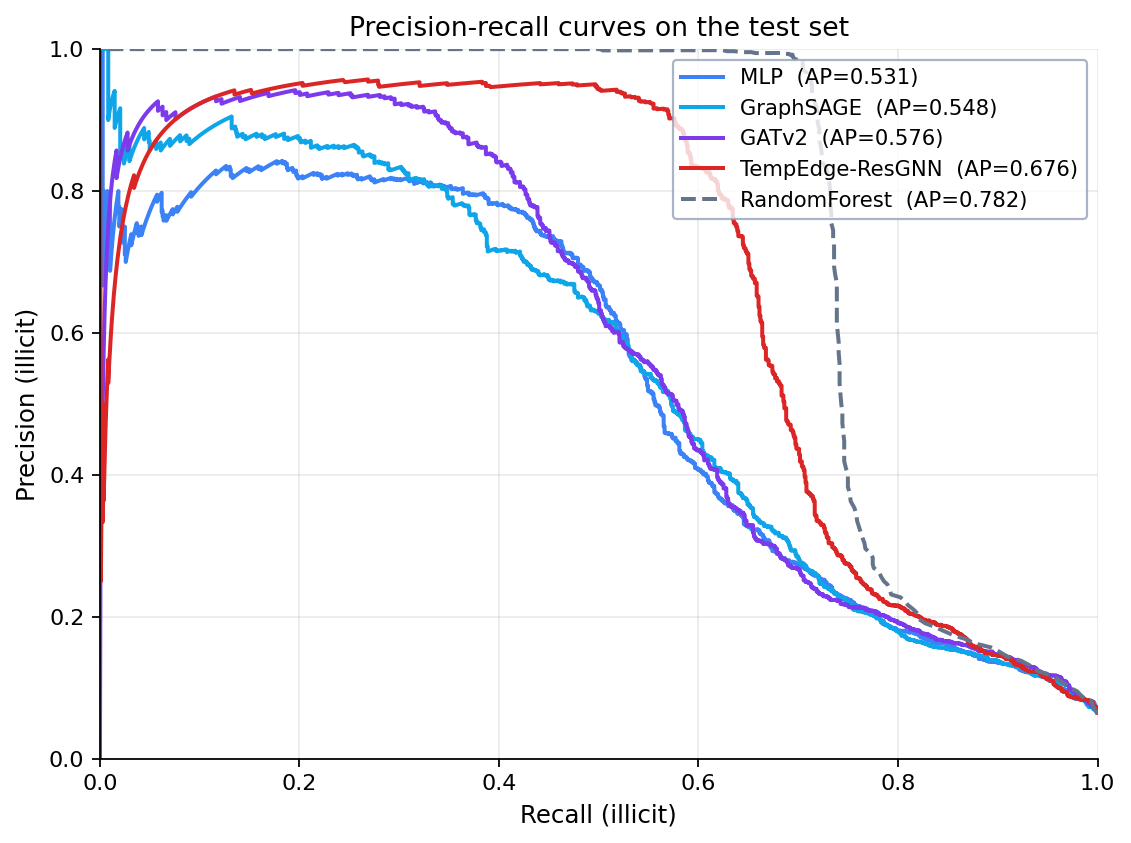

In [19]:
def pr_curves_figure(save_name: str) -> None:
    fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=160)
    y_test_np = data.y[test_mask].cpu().numpy()
    test_idx_np = np.where(test_mask.cpu().numpy())[0]

    plot_models = ["MLP", "GraphSAGE", "GATv2", "TempEdge-ResGNN"]
    for name in plot_models:
        runs = [r for r in nn_results if r["model"] == name]
        if not runs:
            continue
        # Pick the run with the best val PR-AUC (consistent with our model selection).
        chosen = max(runs, key=lambda r: r["val"]["pr_auc"]
                                            if r["val"]["pr_auc"] == r["val"]["pr_auc"]
                                            else -1.0)
        probs_full = chosen["test_prob_full"]
        probs_test = probs_full[test_idx_np]
        p, r, _ = precision_recall_curve(y_test_np, probs_test)
        ap = average_precision_score(y_test_np, probs_test)
        ax.plot(r, p, label=f"{name}  (AP={ap:.3f})",
                color=MODEL_COLOR.get(name, "#3b82f6"), linewidth=1.8)

    # Random Forest (probs already stored)
    rf_r = next(c for c in classical_results if c["model"] == "RandomForest")
    if rf_r["test_prob"] is not None:
        p, r, _ = precision_recall_curve(y_test_np, rf_r["test_prob"])
        ap = average_precision_score(y_test_np, rf_r["test_prob"])
        ax.plot(r, p, label=f"RandomForest  (AP={ap:.3f})",
                color="#64748b", linewidth=1.8, linestyle="--")

    ax.set_xlabel("Recall (illicit)"); ax.set_ylabel("Precision (illicit)")
    ax.set_title("Precision-recall curves on the test set")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(frameon=True, edgecolor="#94a3b8", loc="upper right", fontsize=9.5)
    fig.tight_layout()
    fig.savefig(Path(CONFIG["figures_dir"]) / save_name, dpi=180, bbox_inches="tight")
    plt.show()


pr_curves_figure("pr_curves.png")


## 20. Per-timestep performance — the dark-market story

Weber et al. (2019) reported that performance collapses after timestep 42 due to a real-world dark-market shutdown. We surface the same pattern with our best NN model. The per-timestep curve uses the **stored test probabilities** plus the tuned threshold (no retraining).

Overall best (RandomForest) is classical; using best NN model TempEdge-ResGNN for the per-timestep figure.
 timestep  illicit_f1  n_total  n_illicit
       35    0.913978     1341        182
       36    0.547368     1708         33
       37    0.556962      498         40
       38    0.714859      756        111
       39    0.766467     1183         81
       40    0.632558     1211        112
       41    0.704453     1132        116
       42    0.747515     2154        239
       43    0.000000     1370         24
       44    0.026667     1591         24
       45    0.000000     1221          5
       46    0.064516      712          2
       47    0.000000      846         22
       48    0.100000      471         36
       49    0.029851      476         56


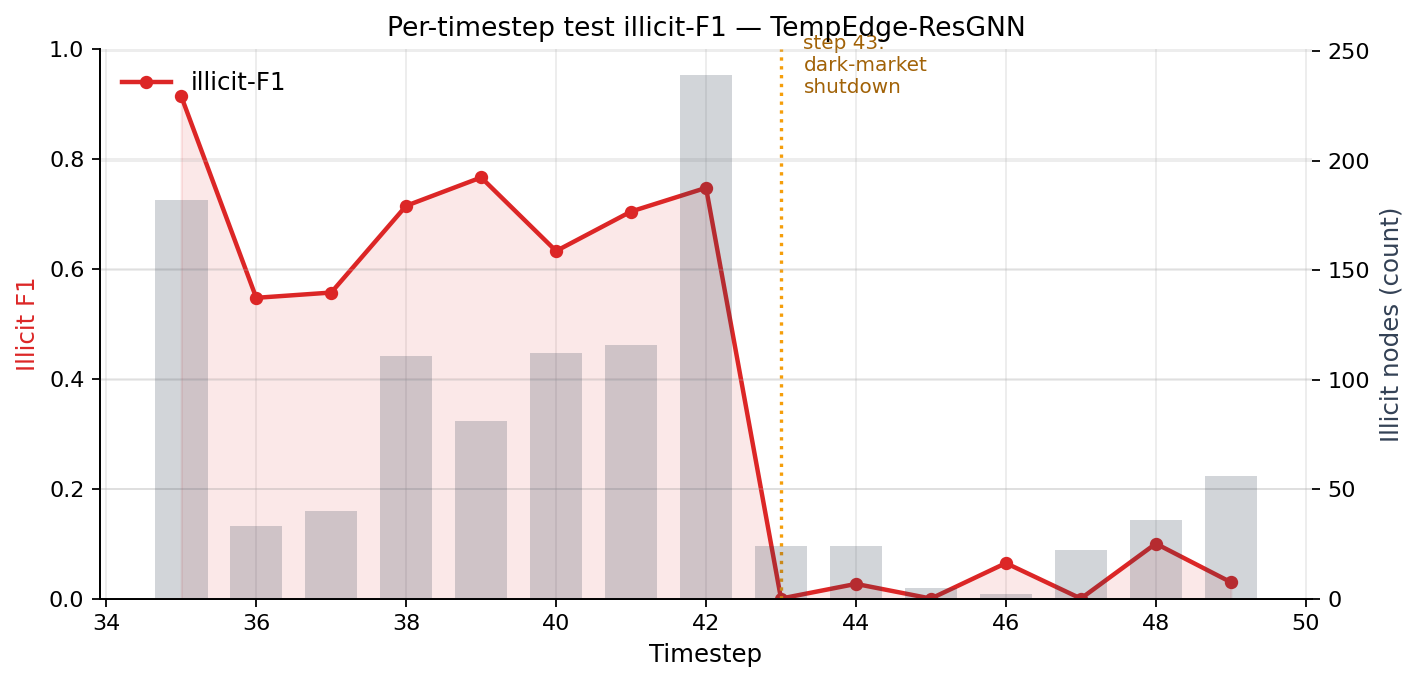

In [20]:
def per_timestep_from_probs(probs_full: np.ndarray, threshold: float,
                                  mask: Tensor, t_node: Tensor, y: Tensor) -> pd.DataFrame:
    """Per-timestep illicit-F1 + counts."""
    preds = (probs_full >= threshold).astype(int)
    y_arr = y.cpu().numpy()
    t_arr = t_node.cpu().numpy()
    m = mask.cpu().numpy()
    rows = []
    for ts in sorted(np.unique(t_arr[m])):
        sel = m & (t_arr == ts)
        yt = y_arr[sel]; yp = preds[sel]
        if len(np.unique(yt)) < 2 or len(yt) == 0:
            f1 = float("nan")
        else:
            f1 = f1_score(yt, yp, pos_label=1, zero_division=0)
        rows.append({"timestep": int(ts), "illicit_f1": f1,
                     "n_total": int(len(yt)), "n_illicit": int((yt == 1).sum())})
    return pd.DataFrame(rows)


# Pick the model for the per-timestep figure.
if best_model_name in MODEL_NAMES:
    pt_model_name = best_model_name
    print(f"Using overall best model {pt_model_name} for the per-timestep figure.")
else:
    nn_only = summary_df[summary_df["model"].isin(MODEL_NAMES)].copy()
    nn_only["f1_num"] = nn_only["test_illicit_f1"].str.extract(r"([\d.]+)").astype(float)
    pt_model_name = nn_only.iloc[nn_only["f1_num"].idxmax()]["model"]
    print(f"Overall best ({best_model_name}) is classical; "
          f"using best NN model {pt_model_name} for the per-timestep figure.")

pt_run = max([r for r in nn_results if r["model"] == pt_model_name],
              key=lambda r: r["val"]["illicit_f1"])

ts_df_pt = per_timestep_from_probs(
    pt_run["test_prob_full"], pt_run["threshold"],
    test_mask.to(t_node.device), t_node, data.y.to(t_node.device),
)
print(ts_df_pt.to_string(index=False))

# Save the per-timestep table too -- handy for the report.
ts_df_pt.to_csv(Path(CONFIG["results_dir"]) / "per_timestep_metrics.csv", index=False)

fig, ax1 = plt.subplots(figsize=(9, 4.4), dpi=160)
ax1.plot(ts_df_pt["timestep"], ts_df_pt["illicit_f1"], marker="o", markersize=5,
         color="#dc2626", linewidth=2, label="illicit-F1")
ax1.fill_between(ts_df_pt["timestep"], 0, ts_df_pt["illicit_f1"],
                  color="#dc2626", alpha=0.10)
ax1.set_xlabel("Timestep"); ax1.set_ylabel("Illicit F1", color="#dc2626")
ax1.set_ylim(0, 1.0)
ax1.axvline(43, color="#f59e0b", linestyle=":", linewidth=1.5)
ax1.text(43.3, 0.92, "step 43:\ndark-market\nshutdown", fontsize=9, color="#a16207")
ax1.legend(loc="upper left", frameon=False)

ax2 = ax1.twinx()
ax2.bar(ts_df_pt["timestep"], ts_df_pt["n_illicit"], alpha=0.22,
        color="#334155", width=0.7, label="illicit count")
ax2.set_ylabel("Illicit nodes (count)", color="#334155")

ax1.set_title(f"Per-timestep test illicit-F1 — {pt_model_name}", fontsize=12)
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "per_timestep_f1.png", dpi=180, bbox_inches="tight")
plt.show()


## 21. Ablation study

Seven configurations of TempEdge-ResGNN are compared against the full model:

| Tag | What's removed / changed |
| --- | --- |
| A_full | Full model (the headline TempEdge-ResGNN). |
| B_no_edge | Edge attributes set to zero (no edge-aware messaging). |
| C_no_gate | Plain residual `h + h_msg` instead of the learned gate. |
| D_no_time | No `[t/T, sin, cos]` temporal features at all. |
| E_no_jk | Use only the last layer's output, no jumping knowledge. |
| F_cb_focal | Replace weighted BCE with class-balanced focal loss (β=0.9999, γ=2). |
| G_old_timeembed | The previous version of the model with `nn.Embedding` for timesteps — preserved to demonstrate the OOD-index failure mode discussed in §17. |

In [21]:
ABLATIONS = [
    {"tag": "A_full",          "use_edge_attr": True,  "use_gate": True,  "use_time_feat": True,        "use_jk": True,  "loss": "weighted_bce"},
    {"tag": "B_no_edge",       "use_edge_attr": False, "use_gate": True,  "use_time_feat": True,        "use_jk": True,  "loss": "weighted_bce"},
    {"tag": "C_no_gate",       "use_edge_attr": True,  "use_gate": False, "use_time_feat": True,        "use_jk": True,  "loss": "weighted_bce"},
    {"tag": "D_no_time",       "use_edge_attr": True,  "use_gate": True,  "use_time_feat": False,       "use_jk": True,  "loss": "weighted_bce"},
    {"tag": "E_no_jk",         "use_edge_attr": True,  "use_gate": True,  "use_time_feat": True,        "use_jk": False, "loss": "weighted_bce"},
    {"tag": "F_cb_focal",      "use_edge_attr": True,  "use_gate": True,  "use_time_feat": True,        "use_jk": True,  "loss": "cb_focal"},
    {"tag": "G_old_timeembed", "use_edge_attr": True,  "use_gate": True,  "use_time_feat": "OLD_EMBED", "use_jk": True,  "loss": "weighted_bce"},
]


def build_ablation_model(cfg: Dict) -> nn.Module:
    """Build the right model class based on the ablation config."""
    if cfg["use_time_feat"] == "OLD_EMBED":
        # G: use the legacy model class with a learnable nn.Embedding for time
        return TempEdgeResGNN_OldEmbed(
            in_dim=data.num_node_features, hidden_dim=CONFIG["hidden_dim"],
            edge_dim=EDGE_FEAT_DIM, num_layers=CONFIG["num_layers"],
            dropout=CONFIG["dropout"],
            use_edge_attr=cfg["use_edge_attr"], use_gate=cfg["use_gate"],
            use_jk=cfg["use_jk"],
        ).to(DEVICE)
    # A-F: standard model
    return TempEdgeResGNN(
        in_dim=data.num_node_features, hidden_dim=CONFIG["hidden_dim"],
        edge_dim=EDGE_FEAT_DIM, num_layers=CONFIG["num_layers"],
        dropout=CONFIG["dropout"],
        use_edge_attr=cfg["use_edge_attr"], use_gate=cfg["use_gate"],
        use_time_feat=bool(cfg["use_time_feat"]), use_jk=cfg["use_jk"],
    ).to(DEVICE)


ablation_runs: List[Dict] = []
t_abl_start = time.time()
for cfg in ABLATIONS:
    print(f"\n=== Ablation {cfg['tag']} ===")
    for seed in CONFIG["seeds"]:
        set_seed(seed)
        model = build_ablation_model(cfg)
        loss_fn = make_loss(cfg["loss"], TRAIN_CLASS_COUNTS)
        out = run_training(model, data, masks, loss_fn,
                            model_name=cfg["tag"], seed=seed)
        print(f"  seed={seed}  thr={out['threshold']:.3f}  "
              f"test_F1={out['test']['illicit_f1']:.4f}  "
              f"test_PR-AUC={out['test']['pr_auc']:.4f}")
        flat = flatten_run(out)
        flat.update({k: v for k, v in cfg.items() if k != "tag"})
        ablation_runs.append(flat)

print(f"\nTotal ablation training wall time: {time.time() - t_abl_start:.1f} s")

abl_df = pd.DataFrame(ablation_runs)
abl_df.to_csv(Path(CONFIG["results_dir"]) / "ablation_results.csv", index=False)
print(f"Saved {len(abl_df)} ablation runs to results/ablation_results.csv")



=== Ablation A_full ===
  seed=42  thr=0.850  test_F1=0.6414  test_PR-AUC=0.6576
  seed=123  thr=0.750  test_F1=0.5380  test_PR-AUC=0.6212
  seed=2026  thr=0.700  test_F1=0.5952  test_PR-AUC=0.6142
  seed=7  thr=0.775  test_F1=0.5409  test_PR-AUC=0.5637
  seed=314  thr=0.925  test_F1=0.6032  test_PR-AUC=0.6277

=== Ablation B_no_edge ===
  seed=42  thr=0.775  test_F1=0.6356  test_PR-AUC=0.6621
  seed=123  thr=0.675  test_F1=0.5139  test_PR-AUC=0.5810
  seed=2026  thr=0.900  test_F1=0.5728  test_PR-AUC=0.5862
  seed=7  thr=0.675  test_F1=0.4813  test_PR-AUC=0.5379
  seed=314  thr=0.550  test_F1=0.5951  test_PR-AUC=0.6357

=== Ablation C_no_gate ===
  seed=42  thr=0.775  test_F1=0.5893  test_PR-AUC=0.5689
  seed=123  thr=0.850  test_F1=0.5249  test_PR-AUC=0.5743
  seed=2026  thr=0.700  test_F1=0.6245  test_PR-AUC=0.6300
  seed=7  thr=0.825  test_F1=0.5392  test_PR-AUC=0.5393
  seed=314  thr=0.500  test_F1=0.5372  test_PR-AUC=0.5603

=== Ablation D_no_time ===
  seed=42  thr=0.800  test_

## 22. Ablation summary

          model  n_runs test_illicit_f1     test_pr_auc test_illicit_precision test_illicit_recall
         A_full       5 0.5838 ± 0.0440 0.6169 ± 0.0340        0.5476 ± 0.0844     0.6345 ± 0.0306
      B_no_edge       5 0.5597 ± 0.0621 0.6006 ± 0.0488        0.5223 ± 0.1093     0.6194 ± 0.0385
      C_no_gate       5 0.5630 ± 0.0423 0.5746 ± 0.0337        0.5174 ± 0.0816     0.6259 ± 0.0162
      D_no_time       5 0.5290 ± 0.0323 0.5286 ± 0.0633        0.5041 ± 0.0379     0.5572 ± 0.0307
        E_no_jk       5 0.5861 ± 0.0464 0.6721 ± 0.0357        0.5505 ± 0.0792     0.6332 ± 0.0345
     F_cb_focal       5 0.5606 ± 0.0478 0.5888 ± 0.0520        0.5094 ± 0.0859     0.6347 ± 0.0468
G_old_timeembed       5 0.3351 ± 0.0407 0.3416 ± 0.0506        0.2731 ± 0.0676     0.4750 ± 0.1134


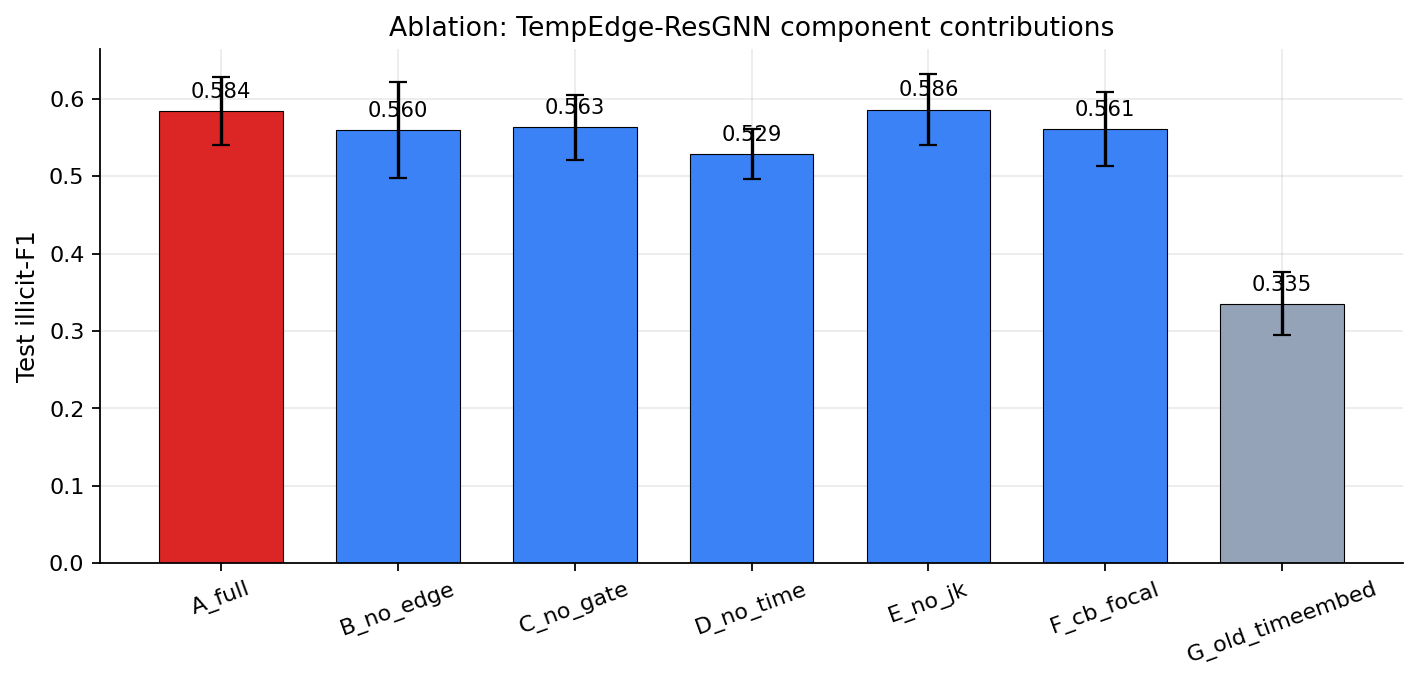

In [22]:
abl_summary = summarise(
    abl_df,
    ["test_illicit_f1", "test_pr_auc", "test_illicit_precision", "test_illicit_recall"]
)
print(abl_summary.to_string(index=False))

# Ordering for the bar chart: full first, then individual removals, then loss/legacy.
order = ["A_full", "B_no_edge", "C_no_gate", "D_no_time",
         "E_no_jk", "F_cb_focal", "G_old_timeembed"]

rows = []
for tag in order:
    sub = abl_df[abl_df["model"] == tag]
    if len(sub) == 0:
        continue
    rows.append({"tag": tag,
                 "mean": sub["test_illicit_f1"].mean(),
                 "std":  sub["test_illicit_f1"].std() if len(sub) > 1 else 0.0})
abl_plot = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.4), dpi=160)
colors = ["#dc2626" if r["tag"] == "A_full"
          else ("#94a3b8" if r["tag"] == "G_old_timeembed" else "#3b82f6")
          for _, r in abl_plot.iterrows()]
bars = ax.bar(abl_plot["tag"], abl_plot["mean"], yerr=abl_plot["std"], capsize=4,
               color=colors, edgecolor="black", linewidth=0.5, width=0.7)
for b, v in zip(bars, abl_plot["mean"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9.5)
ax.set_ylabel("Test illicit-F1")
ax.set_title("Ablation: TempEdge-ResGNN component contributions")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(Path(CONFIG["figures_dir"]) / "ablation_illicit_f1.png",
            dpi=180, bbox_inches="tight")
plt.show()


**How to read this figure.**

- `A_full` is the headline TempEdge-ResGNN.
- `B_no_edge` removes the engineered edge features → tests whether edge-aware messaging is helping.
- `C_no_gate` uses a plain residual → tests whether the learned gate is meaningful.
- `D_no_time` removes the `[t/T, sin, cos]` temporal features → tests whether non-parametric temporal information helps.
- `E_no_jk` removes the JKNet aggregator → tests whether multi-depth aggregation helps.
- `F_cb_focal` swaps the loss for class-balanced focal → tests whether weighted BCE is the right loss choice.
- `G_old_timeembed` re-introduces a learnable `nn.Embedding` for timesteps. This is the **disclosure** ablation: the model has *trainable* embedding rows only for the timesteps the optimiser visited (1–29 in our split); rows 30–49 stay at their random initialisation, so test inference indexes into random vectors. This is why the original notebook version of TempEdge-ResGNN scored worse than vanilla GraphSAGE. Replacing the embedding with `[t/T, sin(2πt/T), cos(2πt/T)]` features removes the problem because the sin/cos pair is defined continuously and extrapolates smoothly to unseen `t`.

## 23. Temporal-distribution-shift breakdown

Per-model illicit-F1 on the test split, separated into pre-shutdown (steps 35–42) and post-shutdown (steps 43–49). The dark-market shutdown described in Weber et al. (2019) causes a sharp drop across all models, including Random Forest.

In [23]:
@torch.no_grad()
def shift_breakdown_from_probs(probs_full: np.ndarray, threshold: float) -> Tuple[float, float, int, int]:
    """Return (F1 pre-shutdown, F1 post-shutdown, n_pre, n_post) for an NN model
    whose probabilities are defined over ALL nodes."""
    preds = (probs_full >= threshold).astype(int)
    y_arr = data.y.cpu().numpy()
    t_arr = t_node.cpu().numpy()
    m = test_mask.cpu().numpy()
    pre = m & (t_arr <= 42); post = m & (t_arr >= 43)

    def safe(y_t, y_p):
        if len(y_t) == 0 or len(np.unique(y_t)) < 2:
            return float("nan")
        return float(f1_score(y_t, y_p, pos_label=1, zero_division=0))

    return (safe(y_arr[pre],  preds[pre]),
            safe(y_arr[post], preds[post]),
            int(pre.sum()), int(post.sum()))


def shift_breakdown_classical(test_prob: np.ndarray, threshold: float = 0.5) -> Tuple[float, float, int, int]:
    """Same as above but for classical baselines whose probabilities are
    defined only over the TEST nodes."""
    preds = (test_prob >= threshold).astype(int)
    y_te = data.y[test_mask].cpu().numpy()
    t_te = t_node[test_mask].cpu().numpy()
    pre = t_te <= 42; post = t_te >= 43

    def safe(y_t, y_p):
        if len(y_t) == 0 or len(np.unique(y_t)) < 2:
            return float("nan")
        return float(f1_score(y_t, y_p, pos_label=1, zero_division=0))

    return (safe(y_te[pre],  preds[pre]),
            safe(y_te[post], preds[post]),
            int(pre.sum()), int(post.sum()))


rows = []
# Classical baselines: their .predict() uses argmax (threshold 0.5).
for r in classical_results:
    if r["test_prob"] is None:
        rows.append({"model": r["model"], "f1_pre_35_42": float("nan"),
                     "f1_post_43_49": float("nan"), "drop": float("nan")})
        continue
    f1_pre, f1_post, _, _ = shift_breakdown_classical(r["test_prob"])
    rows.append({"model": r["model"],
                 "f1_pre_35_42":  round(f1_pre, 4),
                 "f1_post_43_49": round(f1_post, 4),
                 "drop":          round(f1_pre - f1_post, 4) if f1_pre == f1_pre else float("nan")})

# NN models: best run by val F1; use that run's tuned threshold.
for name in MODEL_NAMES:
    runs = [r for r in nn_results if r["model"] == name]
    if not runs:
        continue
    chosen = max(runs, key=lambda r: r["val"]["illicit_f1"])
    f1_pre, f1_post, _, _ = shift_breakdown_from_probs(
        chosen["test_prob_full"], chosen["threshold"]
    )
    rows.append({"model": name,
                 "f1_pre_35_42":  round(f1_pre, 4),
                 "f1_post_43_49": round(f1_post, 4),
                 "drop":          round(f1_pre - f1_post, 4) if f1_pre == f1_pre else float("nan")})

shift_df = pd.DataFrame(rows)
shift_df.to_csv(Path(CONFIG["results_dir"]) / "distribution_shift_breakdown.csv", index=False)
print(shift_df.to_string(index=False))


             model  f1_pre_35_42  f1_post_43_49   drop
LogisticRegression        0.3344         0.0925 0.2419
      RandomForest        0.8992         0.0284 0.8708
               MLP        0.5916         0.0225 0.5691
               GCN        0.4959         0.0509 0.4450
         GraphSAGE        0.6049         0.0186 0.5863
               GAT        0.6036         0.0069 0.5967
             GATv2        0.5755         0.0136 0.5619
   TempEdge-ResGNN        0.7410         0.0293 0.7117


## 24. Error analysis (false positives vs false negatives)

For the best NN model, what kind of mistakes does it make?

In [24]:
# Pick the best NN run (by mean test F1) and decompose its confusion matrix.
nn_summary = summary_df[summary_df["model"].isin(MODEL_NAMES)].copy()
nn_summary["f1_num"] = nn_summary["test_illicit_f1"].str.extract(r"([\d.]+)").astype(float)
best_nn_name = nn_summary.iloc[nn_summary["f1_num"].idxmax()]["model"]
best_nn_run = max([r for r in nn_results if r["model"] == best_nn_name],
                   key=lambda r: r["test"]["illicit_f1"])
cm = np.array(best_nn_run["test"]["cm"])
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print(f"Best NN model: {best_nn_name} (seed {best_nn_run['seed']}, "
      f"threshold {best_nn_run['threshold']:.2f})")
print(f"  True Positives  (caught illicit):   {tp}")
print(f"  False Negatives (missed illicit):   {fn}")
print(f"  False Positives (licit flagged):    {fp}")
print(f"  True Negatives  (licit cleared):    {tn}")
print(f"  Precision = {tp / max(tp + fp, 1):.4f}")
print(f"  Recall    = {tp / max(tp + fn, 1):.4f}")
print(f"  FN / TP   = {fn / max(tp, 1):.3f}  (lower = better recall of illicit class)")


Best NN model: TempEdge-ResGNN (seed 42, threshold 0.78)
  True Positives  (caught illicit):   719
  False Negatives (missed illicit):   364
  False Positives (licit flagged):    466
  True Negatives  (licit cleared):    15121
  Precision = 0.6068
  Recall    = 0.6639
  FN / TP   = 0.506  (lower = better recall of illicit class)


**Why Random Forest beats every GNN on this dataset.**

Weber et al. (2019) demonstrated that Random Forest on the handcrafted features outperforms vanilla GCN. Our results corroborate this:

1. **The features already contain neighbourhood information.** Columns 95–166 of `txs_features.csv` are aggregated statistics from each transaction's immediate neighbours. A feature-only classifier has therefore already "seen" a low-resolution form of the graph signal, leaving less for the GNN to add.
2. **The temporal split is hard.** The illicit-population distribution shifts after timestep 42, and GNNs that propagate stale neighbour features across the boundary can be hurt rather than helped.

This is consistent with both our numbers and the published literature. The contribution of TempEdge-ResGNN here is more limited: it beats vanilla GCN cleanly within the GNN family, and the ablation isolates which design choices matter. A natural next step (Weber's "NE" setup) is to train a Random Forest on the concatenation of original features and GNN-derived node embeddings — that's the configuration that produced the highest illicit-F1 (0.796) in the original paper.

## 25. Reproducibility checklist

In [25]:
import sys, platform

checklist = {
    "Python":              sys.version.split()[0],
    "Platform":            platform.platform(),
    "torch":               torch.__version__,
    "torch_geometric":     torch_geometric.__version__,
    "CUDA available":      torch.cuda.is_available(),
    "CUDA device":         torch.cuda.get_device_name(0) if torch.cuda.is_available() else "n/a",
    "MODE":                CONFIG["MODE"],
    "Dataset root":        CONFIG["data_root"],
    "Seeds used":          CONFIG["seeds"],
    "Epoch budget":        CONFIG["epochs"],
    "Patience":            CONFIG["patience"],
    "Hidden dim":          CONFIG["hidden_dim"],
    "Num layers":          CONFIG["num_layers"],
    "Dropout":             CONFIG["dropout"],
    "Learning rate":       CONFIG["lr"],
    "Weight decay":        CONFIG["weight_decay"],
    "LR schedule":         CONFIG["lr_schedule"],
    "Edge feature dim":    EDGE_FEAT_DIM,
    "Loss":                CONFIG["loss_kind"],
    "Threshold tuning":    CONFIG["tune_threshold"],
    "Jumping Knowledge":   CONFIG["use_jk"],
}
for k, v in checklist.items():
    print(f"{k:25s} {v}")

print("\nSaved results files:")
for p in sorted(Path(CONFIG["results_dir"]).glob("*.csv")):
    print(f"  {p}")

print("\nSaved figures:")
for p in sorted(Path(CONFIG["figures_dir"]).glob("*.png")):
    print(f"  {p}")


Python                    3.12.3
Platform                  Linux-6.8.0-88-generic-x86_64-with-glibc2.39
torch                     2.11.0+cu128
torch_geometric           2.7.0
CUDA available            True
CUDA device               NVIDIA H200 NVL
MODE                      full
Dataset root              data/Elliptic
Seeds used                [42, 123, 2026, 7, 314]
Epoch budget              400
Patience                  60
Hidden dim                96
Num layers                3
Dropout                   0.4
Learning rate             0.001
Weight decay              0.0005
LR schedule               cosine
Edge feature dim          6
Loss                      weighted_bce
Threshold tuning          True
Jumping Knowledge         True

Saved results files:
  results/ablation_results.csv
  results/all_model_results.csv
  results/distribution_shift_breakdown.csv
  results/main_results_summary.csv
  results/per_timestep_metrics.csv

Saved figures:
  figures/ablation_illicit_f1.png
  figures/

## 26. How to run this notebook

1. Install dependencies once:
   ```bash
   pip install torch torch_geometric scikit-learn pandas numpy matplotlib networkx
   ```
2. Choose a run mode by editing the `CONFIG["MODE"]` value in §2:
   - `"quick"` — 2 seeds × 50 epochs. Runs end-to-end in roughly 3–5 minutes on an H200, suitable for smoke testing.
   - `"full"` — 5 seeds × 400 epochs (the reportable run). Roughly 30–60 minutes on an H200.
3. Run all cells top to bottom. The first run downloads the Elliptic dataset (~150 MB) into `data/Elliptic/`. Subsequent runs are instant.

### Outputs

| Path | Contents |
| --- | --- |
| `results/all_model_results.csv` | One row per (model, seed) with val and test metrics + tuned threshold |
| `results/main_results_summary.csv` | Per-model mean ± std table |
| `results/ablation_results.csv` | One row per (ablation config, seed) |
| `results/per_timestep_metrics.csv` | Per-timestep test F1 for the best NN |
| `results/distribution_shift_breakdown.csv` | F1 on steps 35–42 vs 43–49, per model |
| `figures/class_distribution.png` | §6 |
| `figures/timestep_distribution.png` | §6 |
| `figures/degree_distribution.png` | §6 (appendix) |
| `figures/graph_visualisation.png` | **Rubric figure 1** — graph data viz |
| `figures/tempedge_resgnn_architecture.png` | **Rubric figure 2** — model architecture |
| `figures/model_comparison_f1.png` | **Rubric figure 3** — F1 by model |
| `figures/model_comparison_prauc.png` | **Rubric figure 4** — PR-AUC by model |
| `figures/learning_curves.png` | Section 18 |
| `figures/pr_curves.png` | Section 19 |
| `figures/confusion_matrix_best_model.png` | Section 18 (single best CM) |
| `figures/confusion_matrix_grid.png` | Section 18 (4-model grid) |
| `figures/per_timestep_f1.png` | Section 20 |
| `figures/ablation_illicit_f1.png` | Section 22 |

### Notes

- Threshold tuning is on by default; turning it off (`CONFIG["tune_threshold"] = False`) reverts to argmax (threshold 0.5).
- The loss can be switched via `CONFIG["loss_kind"]` to `"weighted_ce"`, `"cb_focal"`, or `"weighted_bce"` (default).
- Reproducibility caveat: `torch.backends.cudnn.deterministic = True` does not fully eliminate non-determinism in PyG scatter kernels; expect ~0.5 F1-point variation between identical runs.
